# COMPARISON OF MOCAP VS CAMERA , MOCAP VS ENCODER , CAMERA VS ENCODER 

In [1]:
# Cell 1
import importlib.util
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R
import cv2
import os
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import toml
import matplotlib.gridspec as gridspec
from math import sqrt
import warnings
from pathlib import Path
from scipy.signal import correlate
warnings.filterwarnings('ignore')
print('Libraries loaded OK')

Libraries loaded OK


## Step 1: Load Multiple Rigid body file

In [2]:
# Cell 2
# ── locate notebook & repo root ───────────────────────────────────────────────
try:
    _nb_file = Path(globals()['__vsc_ipynb_file__']).resolve()
    _nb_dir  = _nb_file.parent
except KeyError:
    _nb_dir = Path.cwd()

repo_root = _nb_dir
for candidate in [_nb_dir, *_nb_dir.parents]:
    if (candidate / 'vaideesh').exists() or (candidate / '.venv').exists():
        repo_root = candidate
        break

print(f'Repo root : {repo_root}')

# ── load multiple_rigid_body module ───────────────────────────────────────────
_script_path = repo_root / 'vaideesh' / 'Analysis' / 'multiple_rigid_body.py'
assert _script_path.exists(), f'Script not found: {_script_path}'

_script_dir = str(_script_path.parent)
if _script_dir not in sys.path:
    sys.path.insert(0, _script_dir)

spec = importlib.util.spec_from_file_location('multiple_rigid_body', _script_path)
mrb  = importlib.util.module_from_spec(spec)
sys.modules['multiple_rigid_body'] = mrb
spec.loader.exec_module(mrb)

# ── bring helper functions into notebook namespace ────────────────────────────
add_datetime_col_3rb   = mrb.add_datetime_col_3rb
trunkate_3_dfs         = mrb.trunkate_3_dfs
trunkate_dfs           = mrb.trunkate_dfs
get_rb_pos_cols        = mrb.get_rb_pos_cols
get_rb_rot_cols        = mrb.get_rb_rot_cols
get_rb_marker_name_3rb = mrb.get_rb_marker_name_3rb


# ══════════════════════════════════════════════════════════════════════════════
# load_csv_auto  —  auto-detects rigid bodies and calls read_3_rigid_body_csv
#
# read_3_rigid_body_csv already accepts 2 or 3 rb_names so there is no
# separate read_2_rigid_body_csv — one function handles both cases.
# trunkate_3_dfs requires exactly 3 DFs; for 2-body files we use trunkate_dfs.
# ══════════════════════════════════════════════════════════════════════════════
def load_csv_auto(csv_path, mrb, truncate=True):
    """
    1. Scan the Motive CSV header to detect rigid body names (any count).
    2. Call mrb.read_3_rigid_body_csv — it accepts 2 or 3 rb_names.
    3. Add datetime column to every body.
    4. Truncate all bodies to their shared time window.
    5. Return (rb_dfs, st_time, detected_names).

    Raises a clear error if fewer than 2 or more than 3 bodies are found,
    since read_3_rigid_body_csv only supports 2-3.
    """
    csv_path = str(csv_path)

    # ── Step 1: detect rigid body names in file order ─────────────────────────
    _raw      = pd.read_csv(csv_path, skiprows=2, header=None, dtype=str)
    _type_row = _raw.iloc[0].fillna('').str.strip().tolist()
    _name_row = _raw.iloc[1].fillna('').str.strip().tolist()

    detected = []
    for t, n in zip(_type_row, _name_row):
        if t == 'Rigid Body' and n and n not in detected:
            detected.append(n)

    n = len(detected)
    print(f'  Detected {n} rigid bod{"y" if n == 1 else "ies"}: {detected}')

    if n not in (2, 3):
        raise ValueError(
            f'load_csv_auto: found {n} rigid bodies {detected} in\n  {csv_path}\n'
            f'read_3_rigid_body_csv supports 2 or 3 bodies only.'
        )

    # ── Step 2: read using the detected names ─────────────────────────────────
    rb_dfs, st_time = mrb.read_3_rigid_body_csv(csv_path, rb_names=detected)

    # ── Step 3: add absolute datetime to every body ───────────────────────────
    rb_dfs = mrb.add_datetime_col_3rb(rb_dfs, st_time)

    # ── Step 4: truncate to shared time window ────────────────────────────────
    if truncate:
        names = list(rb_dfs.keys())
        if n == 3:
            # trunkate_3_dfs requires exactly 3 positional DataFrames
            rb_dfs[names[0]], rb_dfs[names[1]], rb_dfs[names[2]] = mrb.trunkate_3_dfs(
                rb_dfs[names[0]], rb_dfs[names[1]], rb_dfs[names[2]],
                display_print=True,
            )
        else:  # n == 2  — trunkate_dfs handles exactly 2
            rb_dfs[names[0]], rb_dfs[names[1]] = mrb.trunkate_dfs(
                rb_dfs[names[0]], rb_dfs[names[1]],
                display_print=True,
            )

    return rb_dfs, st_time, detected


# ── File paths — only these two lines need changing per experiment ─────────────
TABLE_FILE = mrb.FILE
NOARK_FILE = "E:\\Ragav\\MS Bio Engineering\\NOARK_backbone\\mocap_data_t1\\linear_t2.csv"

# TABLE file — geometry only. Timestamps from this file are NEVER used.
print(f'Loading TABLE file (geometry only): {TABLE_FILE}')
table_rb_dfs, table_st_time, table_bodies = load_csv_auto(TABLE_FILE, mrb)

for required in ('tframe', 'table'):
    assert required in table_rb_dfs, (
        f'"{required}" not found in TABLE file. '
        f'Detected bodies: {table_bodies}'
    )

# NOARK file — all time-series data comes from here
print(f'\nLoading NOARK file (experiment data): {NOARK_FILE}')
noark_rb_dfs, noark_st_time, noark_bodies = load_csv_auto(NOARK_FILE, mrb)

# Merge — tframe + table from table file, noark from NOARK file
rb_dfs = {
    'tframe': table_rb_dfs['tframe'],
    'table' : table_rb_dfs['table'],
}
for k, v in noark_rb_dfs.items():
    if k not in ('tframe', 'table'):
        rb_dfs[k] = v

print(f'\nCombined rb_dfs keys : {list(rb_dfs.keys())}')
print(f'Script loaded        : {_script_path}')
print(f'TABLE file st_time (geometry only, NOT used for alignment): {table_st_time}')
print(f'NOARK file st_time (used for all time alignment)          : {noark_st_time}')

Repo root : E:\Ragav\MS Bio Engineering\NOARK_backbone
Loading TABLE file (geometry only): E:\Ragav\MS Bio Engineering\NOARK_backbone\mocap_data_t1\table_frame_t2.csv
  Detected 2 rigid bodies: ['table', 'tframe']
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 125

Loading NOARK file (experiment data): E:\Ragav\MS Bio Engineering\NOARK_backbone\mocap_data_t1\linear_t2.csv
  Detected 2 rigid bodies: ['noark', 'table']
df_2 starts earlier, trimmed from index 0
df_2 ends later, trimmed to index 1447

Combined rb_dfs keys : ['tframe', 'table', 'noark']
Script loaded        : E:\Ragav\MS Bio Engineering\NOARK_backbone\vaideesh\Analysis\multiple_rigid_body.py
TABLE file st_time (geometry only, NOT used for alignment): 2026-04-23 11:30:45.665000
NOARK file st_time (used for all time alignment)          : 2026-04-23 11:49:48.118000


## Verify Data frames

In [3]:
# Cell 3
print('DataFrames from multiple_rigid_body.py:')
print(f'{"Body":<10}  {"Shape":<15}  {"Has time col"}')
print('-' * 40)
for name, df in rb_dfs.items():
    has_time = 'time' in df.columns
    print(f'{name:<10}  {str(df.shape):<15}  {has_time}')

print('\nNaN rows per body:')
for name, df in rb_dfs.items():
    nan_rows = df.isna().any(axis=1).sum()
    print(f'  {name}: {nan_rows} NaN rows out of {len(df)}')

DataFrames from multiple_rigid_body.py:
Body        Shape            Has time col
----------------------------------------
tframe      (126, 27)        True
table       (126, 35)        True
noark       (1448, 27)       True

NaN rows per body:
  tframe: 1 NaN rows out of 126
  table: 1 NaN rows out of 126
  noark: 1 NaN rows out of 1448


## Inspect RAW DATAFRAMES

In [4]:
# Cell 4
# Tframe is the most critical since it defines the coordinate system, so we check it first.
print('── tframe ──')
display(rb_dfs['tframe'].head(3))

── tframe ──


,frame,seconds,tframe_rot_x,tframe_rot_y,tframe_rot_z,tframe_rot_w,tframe_pos_x,tframe_pos_y,tframe_pos_z,tframe_pos_err,...,tframe_marker_m2_mq,tframe_marker_m3_x,tframe_marker_m3_y,tframe_marker_m3_z,tframe_marker_m3_mq,tframe_marker_m4_x,tframe_marker_m4_y,tframe_marker_m4_z,tframe_marker_m4_mq,time
0,0,0.00,-0.231091,0.183901,0.154234,-0.942862,0.058827,-0.000860,-0.382111,0.001108,...,0.844577,0.051391,0.078589,-0.405419,0.368498,0.120590,0.076748,-0.374935,0.843236,2026-04-23 11:30:45.665
1,1,0.01,-0.231052,0.183939,0.154266,-0.942859,0.058801,-0.000871,-0.382124,0.001083,...,0.844577,0.051373,0.078577,-0.405437,0.368498,0.120571,0.076731,-0.374951,0.843236,2026-04-23 11:30:45.675
2,2,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-23 11:30:45.685


In [5]:
# Cell 5
# NOARK body is next most critical since it contains the data we want to compare against, so we check it next.
noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
print(f'── {noark_key} ──')
display(rb_dfs[noark_key].head(3))

── noark ──


,frame,seconds,noark_rot_x,noark_rot_y,noark_rot_z,noark_rot_w,noark_pos_x,noark_pos_y,noark_pos_z,noark_pos_err,...,noark_marker_m2_mq,noark_marker_m3_x,noark_marker_m3_y,noark_marker_m3_z,noark_marker_m3_mq,noark_marker_m4_x,noark_marker_m4_y,noark_marker_m4_z,noark_marker_m4_mq,time
0,0,0.00,0.004413,0.351194,0.001875,-0.936291,0.379602,0.080160,-0.295498,0.000888,...,0.730964,0.429591,0.059913,-0.303965,0.846506,0.380245,0.080406,-0.384732,0.828438,2026-04-23 11:49:48.118
1,1,0.01,0.004487,0.351188,0.001876,-0.936292,0.379595,0.080173,-0.295507,0.000912,...,0.720183,0.429582,0.059921,-0.303972,0.844984,0.380237,0.080406,-0.384742,0.827618,2026-04-23 11:49:48.128
2,2,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-23 11:49:48.138


In [6]:
# Cell 6
#TABLE body is least critical since it's only used for time alignment, so we check it last. 
print('── table ──')
display(rb_dfs['table'].head(3))

── table ──


,frame,seconds,table_rot_x,table_rot_y,table_rot_z,table_rot_w,table_pos_x,table_pos_y,table_pos_z,table_pos_err,...,table_marker_m4_mq,table_marker_m5_x,table_marker_m5_y,table_marker_m5_z,table_marker_m5_mq,table_marker_m6_x,table_marker_m6_y,table_marker_m6_z,table_marker_m6_mq,time
0,0,0.00,0.001328,0.027866,0.000952,-0.99961,0.090967,0.009496,0.119062,0.000385,...,0.961557,0.019091,0.037214,0.312778,0.87221,0.609090,-0.014804,-0.320711,0.813374,2026-04-23 11:30:45.665
1,1,0.01,0.001330,0.027863,0.000948,-0.99961,0.090967,0.009504,0.119056,0.000384,...,0.961557,0.019093,0.037221,0.312772,0.87221,0.609088,-0.014794,-0.320720,0.813374,2026-04-23 11:30:45.675
2,2,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-23 11:30:45.685


## Cell 5 — Define `transform_to_tframe()`

**Coordinate frame construction (per frame, from mocap marker positions):**

| Step | Detail |
|---|---|
| Origin | `tframe_marker_1` position in mocap frame |
| X axis | `tframe_marker_2 − origin`, normalised |
| Y axis | `tframe_marker_4 − origin`, Gram-Schmidt orthogonalised then normalised |
| Z axis | `X × Y` (right-handed) |
| Translation reference | `tframe_marker_1` → becomes **(0, 0, 0)** in table frame |

**Transform formula:** `p_table = R_mocap2table.T @ (p_mocap − t_mocap)`  
where `R_mocap2table` columns are `[vxnorm, vynorm, vznorm]` and `t_mocap = tvec(tframe_marker_3)`.

**Units:** Motive exports positions in **metres** — no conversion needed.  
**Column suffix `_m`** makes the unit explicit in every position column.

In [7]:
# Cell 7
def transform_to_tframe(rb_dfs):
    tframe_df = rb_dfs['tframe'].copy()
    noark_key = [k for k in rb_dfs.keys() if k not in ('tframe', 'table')][0]
    noark_df  = rb_dfs[noark_key].copy()
    print(f'Using noark key: "{noark_key}"')
    table_df  = rb_dfs['table'].copy()

    # ── Build a SINGLE fixed coordinate frame from mean tframe marker positions ──
    m1 = tframe_df[['tframe_marker_m1_x', 'tframe_marker_m1_y', 'tframe_marker_m1_z']].mean().values.astype(float)
    m2 = tframe_df[['tframe_marker_m2_x', 'tframe_marker_m2_y', 'tframe_marker_m2_z']].mean().values.astype(float)
    m3 = tframe_df[['tframe_marker_m4_x', 'tframe_marker_m4_y', 'tframe_marker_m4_z']].mean().values.astype(float)

    # Origin = m1, X = m2 - m1, Y = m3 - m1
    org = m1
    v1  = m2 - org # X-axis coordinate
    v2  = m3 - org  # Y-axis coordinate

    # Gram-Schmidt orthonormalisation → single fixed rotation matrix
    vxnorm = v1 / np.linalg.norm(v1)
    vycap  = v2 - np.dot(v2, vxnorm) * vxnorm
    vynorm = vycap / np.linalg.norm(vycap)
    vznorm = np.cross(vxnorm, vynorm)

    R_mat  = np.stack([vxnorm, vynorm, vznorm], axis=-1)  # (3, 3) — fixed
    t_vec  = m1                                            # fixed origin in mocap frame

    # ── Helper: transform any (N,3) array into table frame ───────────────────
    def pos_to_tframe(p_mocap):
        return (R_mat.T @ (p_mocap - t_vec).T).T          # (N, 3)

    # ── noark ─────────────────────────────────────────────────────────────────
    noark_result = pd.DataFrame({
        'frame'  : noark_df['frame'].values,
        'seconds': noark_df['seconds'].values,
        'time'   : noark_df['time'].values,
    })

    for col_suffix, out_suffix in [('m2', 'noark_m2'), ('m5', 'noark_m5')]:
        try:
            p = noark_df[[f'{noark_key}_marker_{col_suffix}_x',
                f'{noark_key}_marker_{col_suffix}_y',
                f'{noark_key}_marker_{col_suffix}_z']].values.astype(float)
            p_tf = pos_to_tframe(p)
            noark_result[f'{out_suffix}_tf_x_m'] = p_tf[:, 0]
            noark_result[f'{out_suffix}_tf_y_m'] = p_tf[:, 1]
            noark_result[f'{out_suffix}_tf_z_m'] = p_tf[:, 2]
        except KeyError:
            print(f'  skipping {col_suffix} — not found in noark columns')

    # ── table ─────────────────────────────────────────────────────────────────
    table_result = pd.DataFrame({
        'frame'  : table_df['frame'].values,
        'seconds': table_df['seconds'].values,
        'time'   : table_df['time'].values,
    })

    for i in range(1, 7):
        try:
            p = table_df[[f'table_marker_m{i}_x',
                           f'table_marker_m{i}_y',
                           f'table_marker_m{i}_z']].values.astype(float)
            p_tf = pos_to_tframe(p)
            table_result[f'table_m{i}_tf_x_m'] = p_tf[:, 0]
            table_result[f'table_m{i}_tf_y_m'] = p_tf[:, 1]
            table_result[f'table_m{i}_tf_z_m'] = p_tf[:, 2]
        except KeyError:
            pass

    return {
        'noark_in_tframe' : noark_result.reset_index(drop=True),
        'table_in_tframe' : table_result.reset_index(drop=True),
        '_R_mat'          : R_mat,
        '_t_vec'          : t_vec,
        '_tframe_m3_mocap': m3,
    }

## RUN THE TRANSFORMATION

In [8]:
# Cell 8
tframe_dfs = transform_to_tframe(rb_dfs)

print('noark_in_tframe shape :', tframe_dfs['noark_in_tframe'].shape)
print('table_in_tframe shape :', tframe_dfs['table_in_tframe'].shape)
print('\nnoark_in_tframe columns:')
print(tframe_dfs['noark_in_tframe'].columns.tolist())
print('\ntable_in_tframe columns:')
print(tframe_dfs['table_in_tframe'].columns.tolist())

Using noark key: "noark"
  skipping m5 — not found in noark columns
noark_in_tframe shape : (1448, 6)
table_in_tframe shape : (126, 21)

noark_in_tframe columns:
['frame', 'seconds', 'time', 'noark_m2_tf_x_m', 'noark_m2_tf_y_m', 'noark_m2_tf_z_m']

table_in_tframe columns:
['frame', 'seconds', 'time', 'table_m1_tf_x_m', 'table_m1_tf_y_m', 'table_m1_tf_z_m', 'table_m2_tf_x_m', 'table_m2_tf_y_m', 'table_m2_tf_z_m', 'table_m3_tf_x_m', 'table_m3_tf_y_m', 'table_m3_tf_z_m', 'table_m4_tf_x_m', 'table_m4_tf_y_m', 'table_m4_tf_z_m', 'table_m5_tf_x_m', 'table_m5_tf_y_m', 'table_m5_tf_z_m', 'table_m6_tf_x_m', 'table_m6_tf_y_m', 'table_m6_tf_z_m']


## INSPECT TRANSFORMED DATAFRAMES

In [9]:
# Cell 9
print('── noark in tframe ──')
display(tframe_dfs['noark_in_tframe'].head())

── noark in tframe ──


,frame,seconds,time,noark_m2_tf_x_m,noark_m2_tf_y_m,noark_m2_tf_z_m
0,0,0.00,2026-04-23 11:49:48.118,-0.267934,0.196630,-0.172542
1,1,0.01,2026-04-23 11:49:48.128,-0.267928,0.196658,-0.172530
2,2,0.02,2026-04-23 11:49:48.138,NaN,NaN,NaN
3,3,0.03,2026-04-23 11:49:48.148,-0.267931,0.196658,-0.172528
4,4,0.04,2026-04-23 11:49:48.158,-0.267925,0.196636,-0.172524


In [10]:
# Cell 10
print('── table in tframe ──')
display(tframe_dfs['table_in_tframe'].head())

── table in tframe ──


,frame,seconds,time,table_m1_tf_x_m,table_m1_tf_y_m,table_m1_tf_z_m,table_m2_tf_x_m,table_m2_tf_y_m,table_m2_tf_z_m,table_m3_tf_x_m,...,table_m3_tf_z_m,table_m4_tf_x_m,table_m4_tf_y_m,table_m4_tf_z_m,table_m5_tf_x_m,table_m5_tf_y_m,table_m5_tf_z_m,table_m6_tf_x_m,table_m6_tf_y_m,table_m6_tf_z_m
0,0,0.00,2026-04-23 11:30:45.665,0.479679,0.038649,-0.771543,-0.506411,0.047677,-0.755100,-0.084477,...,-0.689546,0.489465,0.068072,-0.026978,0.045251,0.083256,-0.690734,-0.493419,0.080434,-0.011072
1,1,0.01,2026-04-23 11:30:45.675,0.479677,0.038654,-0.771539,-0.506412,0.047689,-0.755091,-0.084477,...,-0.689540,0.489467,0.068075,-0.026975,0.045250,0.083264,-0.690728,-0.493416,0.080444,-0.011064
2,2,0.02,2026-04-23 11:30:45.685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0.03,2026-04-23 11:30:45.695,0.479678,0.038641,-0.771538,-0.506412,0.047669,-0.755097,-0.084479,...,-0.689544,0.489462,0.068099,-0.026974,0.045249,0.083251,-0.690732,-0.493422,0.080461,-0.011071
4,4,0.04,2026-04-23 11:30:45.705,0.479678,0.038643,-0.771541,-0.506412,0.047661,-0.755096,-0.084478,...,-0.689544,0.489465,0.068083,-0.026977,0.045250,0.083247,-0.690732,-0.493418,0.080435,-0.011069


## SANITY CHECKS

In [11]:
# Cell 11
# ── Sanity checks — fixed (3,3) rotation matrix ──────────────────────────────
R_mat = tframe_dfs['_R_mat']           # (3,3)
t_vec = tframe_dfs['_t_vec']           # (3,) — tframe_marker_1 = origin

def _chk(label, val, tol, unit=''):
    print(f'  {label:<46} {val:.2e} {unit}  →  {"PASS ✓" if val < tol else "FAIL ✗"}')

print('Sanity checks')
print('─' * 62)

# Check 1: origin (t_vec = m1) maps to (0,0,0)
p_origin = R_mat.T @ (t_vec - t_vec)
_chk('Check 1  origin (tframe_m1) → (0,0,0)', np.max(np.abs(p_origin)), 1e-10, 'm')

# Check 2: R columns are unit vectors
col_norms = np.linalg.norm(R_mat, axis=0)
_chk('Check 2  R columns are unit vectors', np.max(np.abs(col_norms - 1.0)), 1e-6)

# Check 3: R.T @ R = I
RtR = R_mat.T @ R_mat
_chk('Check 3  R.T @ R = I  (orthogonality)', np.max(np.abs(RtR - np.eye(3))), 1e-6)

# Check 4: det(R) = +1
det = np.linalg.det(R_mat)
print(f'  {"Check 4  det(R) = +1  (right-handed)":<46} det = {det:.8f}  →  {"PASS ✓" if abs(det-1.0)<1e-6 else "FAIL ✗"}')

print(f'\nR_mat (columns = X/Y/Z axes of table frame in mocap):\n{np.round(R_mat, 6)}')
print(f'\nt_vec (table origin = tframe_m1 in mocap, m): {np.round(t_vec, 6)}')

Sanity checks
──────────────────────────────────────────────────────────────
  Check 1  origin (tframe_m1) → (0,0,0)          0.00e+00 m  →  PASS ✓
  Check 2  R columns are unit vectors            2.22e-16   →  PASS ✓
  Check 3  R.T @ R = I  (orthogonality)          3.33e-16   →  PASS ✓
  Check 4  det(R) = +1  (right-handed)           det = 1.00000000  →  PASS ✓

R_mat (columns = X/Y/Z axes of table frame in mocap):
[[-0.996399  0.032013  0.078509]
 [ 0.028129  0.998348 -0.050095]
 [-0.079983 -0.047707 -0.995654]]

t_vec (table origin = tframe_m1 in mocap, m): [ 0.115742 -0.08178  -0.367363]


## NOARK POSITION IN TABLE FRAME 

In [12]:
# Cell 12 — noark m2
df_n = tframe_dfs['noark_in_tframe']
print('noark Marker 2 — position in tframe coordinate system (metres)')
print(df_n[['frame','seconds','noark_m2_tf_x_m','noark_m2_tf_y_m','noark_m2_tf_z_m']].to_string(index=False))
print('\nSummary statistics (metres):')
display(df_n[['noark_m2_tf_x_m','noark_m2_tf_y_m','noark_m2_tf_z_m']].describe().round(6))

noark Marker 2 — position in tframe coordinate system (metres)
 frame  seconds  noark_m2_tf_x_m  noark_m2_tf_y_m  noark_m2_tf_z_m
     0     0.00        -0.267934         0.196630        -0.172542
     1     0.01        -0.267928         0.196658        -0.172530
     2     0.02              NaN              NaN              NaN
     3     0.03        -0.267931         0.196658        -0.172528
     4     0.04        -0.267925         0.196636        -0.172524
     5     0.05        -0.267922         0.196670        -0.172527
     6     0.06        -0.267925         0.196658        -0.172532
     7     0.07        -0.267913         0.196645        -0.172536
     8     0.08        -0.267928         0.196647        -0.172538
     9     0.09        -0.267929         0.196661        -0.172543
    10     0.10        -0.267918         0.196665        -0.172544
    11     0.11        -0.267922         0.196668        -0.172545
    12     0.12        -0.267925         0.196657        -0.172545

,noark_m2_tf_x_m,noark_m2_tf_y_m,noark_m2_tf_z_m
count,1447.000000,1447.000000,1447.000000
mean,-0.117882,0.190716,-0.271075
std,0.185233,0.004641,0.079654
min,-0.270082,0.181847,-0.384411
25%,-0.266248,0.186979,-0.368634
50%,-0.248951,0.190875,-0.214600
75%,0.004888,0.195072,-0.207785
max,0.236271,0.196975,-0.172524


## TABLE MARKER POSITION P1-P4 AND MOTOR POSITION M1 AND M2

In [13]:
# Cell 13
df_t = tframe_dfs['table_in_tframe']
for i in range(1, 7):
    cols = [f'table_m{i}_tf_x_m', f'table_m{i}_tf_y_m', f'table_m{i}_tf_z_m']
    print(f'\ntable Marker {i} — position in tframe coordinate system (metres)')
    print(df_t[['frame','seconds'] + cols].to_string(index=False))
    print(f'\nSummary statistics — Marker {i} (metres):')
    display(df_t[cols].describe().round(6))


table Marker 1 — position in tframe coordinate system (metres)
 frame  seconds  table_m1_tf_x_m  table_m1_tf_y_m  table_m1_tf_z_m
     0     0.00         0.479679         0.038649        -0.771543
     1     0.01         0.479677         0.038654        -0.771539
     2     0.02              NaN              NaN              NaN
     3     0.03         0.479678         0.038641        -0.771538
     4     0.04         0.479678         0.038643        -0.771541
     5     0.05         0.479681         0.038632        -0.771539
     6     0.06         0.479682         0.038626        -0.771541
     7     0.07         0.479684         0.038622        -0.771542
     8     0.08         0.479681         0.038627        -0.771537
     9     0.09         0.479678         0.038630        -0.771537
    10     0.10         0.479681         0.038641        -0.771539
    11     0.11         0.479682         0.038628        -0.771543
    12     0.12         0.479690         0.038646        -0.77154

,table_m1_tf_x_m,table_m1_tf_y_m,table_m1_tf_z_m
count,125.000000,125.000000,125.000000
mean,0.479681,0.038629,-0.771542
std,0.000008,0.000014,0.000009
min,0.479671,0.038542,-0.771603
25%,0.479677,0.038623,-0.771543
50%,0.479680,0.038629,-0.771541
75%,0.479682,0.038636,-0.771538
max,0.479738,0.038654,-0.771526



table Marker 2 — position in tframe coordinate system (metres)
 frame  seconds  table_m2_tf_x_m  table_m2_tf_y_m  table_m2_tf_z_m
     0     0.00        -0.506411         0.047677        -0.755100
     1     0.01        -0.506412         0.047689        -0.755091
     2     0.02              NaN              NaN              NaN
     3     0.03        -0.506412         0.047669        -0.755097
     4     0.04        -0.506412         0.047661        -0.755096
     5     0.05        -0.506409         0.047653        -0.755100
     6     0.06        -0.506408         0.047654        -0.755099
     7     0.07        -0.506405         0.047666        -0.755102
     8     0.08        -0.506410         0.047670        -0.755097
     9     0.09        -0.506412         0.047671        -0.755099
    10     0.10        -0.506409         0.047672        -0.755097
    11     0.11        -0.506408         0.047669        -0.755096
    12     0.12        -0.506400         0.047665        -0.75510

,table_m2_tf_x_m,table_m2_tf_y_m,table_m2_tf_z_m
count,125.000000,125.000000,125.000000
mean,-0.506409,0.047672,-0.755098
std,0.000008,0.000011,0.000012
min,-0.506418,0.047611,-0.755191
25%,-0.506412,0.047667,-0.755099
50%,-0.506409,0.047672,-0.755097
75%,-0.506408,0.047678,-0.755093
max,-0.506352,0.047698,-0.755088



table Marker 3 — position in tframe coordinate system (metres)
 frame  seconds  table_m3_tf_x_m  table_m3_tf_y_m  table_m3_tf_z_m
     0     0.00        -0.084477         0.084672        -0.689546
     1     0.01        -0.084477         0.084681        -0.689540
     2     0.02              NaN              NaN              NaN
     3     0.03        -0.084479         0.084667        -0.689544
     4     0.04        -0.084478         0.084661        -0.689544
     5     0.05        -0.084475         0.084654        -0.689547
     6     0.06        -0.084473         0.084651        -0.689546
     7     0.07        -0.084471         0.084657        -0.689548
     8     0.08        -0.084475         0.084659        -0.689542
     9     0.09        -0.084478         0.084662        -0.689545
    10     0.10        -0.084475         0.084667        -0.689543
    11     0.11        -0.084473         0.084660        -0.689544
    12     0.12        -0.084467         0.084666        -0.68954

...

,table_m4_tf_x_m,table_m4_tf_y_m,table_m4_tf_z_m
count,125.000000,125.000000,125.000000
mean,0.489469,0.068072,-0.026978
std,0.000006,0.000010,0.000009
min,0.489456,0.068042,-0.027040
25%,0.489465,0.068065,-0.026979
50%,0.489468,0.068071,-0.026977
75%,0.489471,0.068080,-0.026974
max,0.489511,0.068099,-0.026963



table Marker 5 — position in tframe coordinate system (metres)
 frame  seconds  table_m5_tf_x_m  table_m5_tf_y_m  table_m5_tf_z_m
     0     0.00         0.045251         0.083256        -0.690734
     1     0.01         0.045250         0.083264        -0.690728
     2     0.02              NaN              NaN              NaN
     3     0.03         0.045249         0.083251        -0.690732
     4     0.04         0.045250         0.083247        -0.690732
     5     0.05         0.045251         0.083238        -0.690733
     6     0.06         0.045254         0.083234        -0.690733
     7     0.07         0.045256         0.083239        -0.690736
     8     0.08         0.045252         0.083241        -0.690729
     9     0.09         0.045250         0.083244        -0.690731
    10     0.10         0.045252         0.083251        -0.690731
    11     0.11         0.045253         0.083242        -0.690733
    12     0.12         0.045261         0.083251        -0.69073

,table_m5_tf_x_m,table_m5_tf_y_m,table_m5_tf_z_m
count,125.000000,125.000000,125.000000
mean,0.045253,0.083245,-0.690733
std,0.000008,0.000011,0.000010
min,0.045243,0.083178,-0.690811
25%,0.045250,0.083240,-0.690734
50%,0.045252,0.083245,-0.690732
75%,0.045254,0.083250,-0.690731
max,0.045309,0.083264,-0.690725



table Marker 6 — position in tframe coordinate system (metres)
 frame  seconds  table_m6_tf_x_m  table_m6_tf_y_m  table_m6_tf_z_m
     0     0.00        -0.493419         0.080434        -0.011072
     1     0.01        -0.493416         0.080444        -0.011064
     2     0.02              NaN              NaN              NaN
     3     0.03        -0.493422         0.080461        -0.011071
     4     0.04        -0.493418         0.080435        -0.011069
     5     0.05        -0.493420         0.080435        -0.011074
     6     0.06        -0.493415         0.080426        -0.011072
     7     0.07        -0.493416         0.080445        -0.011076
     8     0.08        -0.493418         0.080439        -0.011069
     9     0.09        -0.493423         0.080440        -0.011073
    10     0.10        -0.493417         0.080448        -0.011070
    11     0.11        -0.493412         0.080440        -0.011069
    12     0.12        -0.493412         0.080434        -0.01107

,table_m6_tf_x_m,table_m6_tf_y_m,table_m6_tf_z_m
count,125.000000,125.000000,125.000000
mean,-0.493415,0.080449,-0.011071
std,0.000006,0.000011,0.000012
min,-0.493427,0.080415,-0.011167
25%,-0.493418,0.080441,-0.011072
50%,-0.493415,0.080449,-0.011070
75%,-0.493412,0.080456,-0.011066
max,-0.493372,0.080474,-0.011061


## XY POSITION OF ALL TABLE MARKERS

In [14]:
# Cell 14
import numpy as np

df_t = tframe_dfs['table_in_tframe'].copy()

print('Mean positions of all table markers in table frame (cm)')
print(f'  {"Marker":<12}  {"X (cm)":>10}  {"Y (cm)":>10}  {"Z (cm)":>10}')
print('-' * 50)
marker_xy = {}
for mid in range(1, 7):
    xc = f'table_m{mid}_tf_x_m'
    yc = f'table_m{mid}_tf_y_m'
    zc = f'table_m{mid}_tf_z_m'
    if xc in df_t.columns:
        x = df_t[xc].mean() * 100
        y = df_t[yc].mean() * 100
        z = df_t[zc].mean() * 100
        marker_xy[mid] = (x, y)
        print(f'  table_m{mid:<6}    {x:>10.2f}  {y:>10.2f}  {z:>10.2f}')
    else:
        print(f'  table_m{mid:<6}    NOT FOUND')

Mean positions of all table markers in table frame (cm)
  Marker            X (cm)      Y (cm)      Z (cm)
--------------------------------------------------
  table_m1              47.97        3.86      -77.15
  table_m2             -50.64        4.77      -75.51
  table_m3              -8.45        8.47      -68.95
  table_m4              48.95        6.81       -2.70
  table_m5               4.53        8.32      -69.07
  table_m6             -49.34        8.04       -1.11


## NOARK Marker 2: X and Z Position Over Time

Plots X and Z position in the table coordinate frame over time.

- **Top subplot**: X position (left ↔ right) over time
- **Bottom subplot**: Z position (up ↕ down) over time
- Axes in **cm** for readability.

Plotting NOARK marker: m2


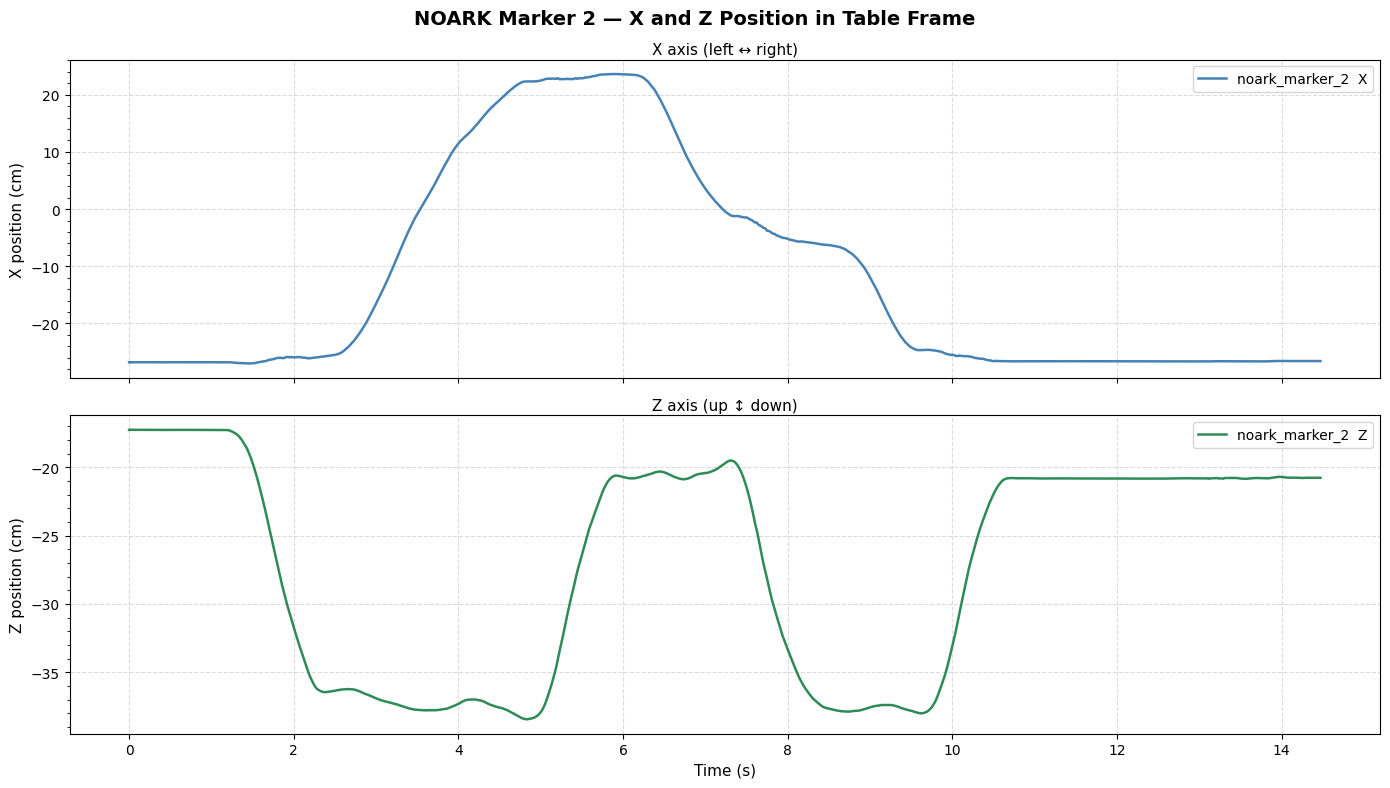

X range: nan → nan cm  (span nan cm)
Z range: nan → nan cm  (span nan cm)
Duration: 14.47 s  (1448 frames)


In [15]:
# Cell 15
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df_n = tframe_dfs['noark_in_tframe'].copy()

# ── Use noark_marker_2 specifically ──────────────────────────────────────────
PLOT_MARKER = 'm2'
assert f'noark_{PLOT_MARKER}_tf_x_m' in df_n.columns, (
    f'noark_{PLOT_MARKER}_tf_x_m not found. Available: {df_n.columns.tolist()}'
)
print(f'Plotting NOARK marker: {PLOT_MARKER}')

cam_t = df_n['seconds'].values
cam_x = df_n[f'noark_{PLOT_MARKER}_tf_x_m'].values * 100.0   # m → cm
cam_z = df_n[f'noark_{PLOT_MARKER}_tf_z_m'].values * 100.0   # m → cm

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('NOARK Marker 2 — X and Z Position in Table Frame',
             fontsize=14, fontweight='bold')

# ── X subplot ─────────────────────────────────────────────────────────────────
ax1.plot(cam_t, cam_x, color='steelblue', lw=1.8, label='noark_marker_2  X')
ax1.set_ylabel('X position (cm)', fontsize=11)
ax1.set_title('X axis (left ↔ right)', fontsize=11, pad=4)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.45)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.tick_params(axis='both', labelsize=10)

# annotate min/max
_xi = np.argmin(cam_x); _xa = np.argmax(cam_x)
ax1.annotate(f'min {cam_x[_xi]:.1f} cm', xy=(cam_t[_xi], cam_x[_xi]),
             xytext=(0, -18), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=8, color='steelblue', ha='center')
ax1.annotate(f'max {cam_x[_xa]:.1f} cm', xy=(cam_t[_xa], cam_x[_xa]),
             xytext=(0, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='steelblue'),
             fontsize=8, color='steelblue', ha='center')

# ── Z subplot ─────────────────────────────────────────────────────────────────
ax2.plot(cam_t, cam_z, color='seagreen', lw=1.8, label='noark_marker_2  Z')
ax2.set_ylabel('Z position (cm)', fontsize=11)
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_title('Z axis (up ↕ down)', fontsize=11, pad=4)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.45)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.tick_params(axis='both', labelsize=10)

# annotate min/max
_zi = np.argmin(cam_z); _za = np.argmax(cam_z)
ax2.annotate(f'min {cam_z[_zi]:.1f} cm', xy=(cam_t[_zi], cam_z[_zi]),
             xytext=(0, -18), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             fontsize=8, color='seagreen', ha='center')
ax2.annotate(f'max {cam_z[_za]:.1f} cm', xy=(cam_t[_za], cam_z[_za]),
             xytext=(0, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             fontsize=8, color='seagreen', ha='center')

plt.tight_layout()
plt.savefig('Mocap_NOARK_position.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'X range: {cam_x.min():.2f} → {cam_x.max():.2f} cm  (span {cam_x.max()-cam_x.min():.2f} cm)')
print(f'Z range: {cam_z.min():.2f} → {cam_z.max():.2f} cm  (span {cam_z.max()-cam_z.min():.2f} cm)')
print(f'Duration: {cam_t[-1] - cam_t[0]:.2f} s  ({len(cam_t)} frames)')

## 2D Trajectory of NOARK Marker 2 (X–Z Table Frame)

Scatter plot of X and Z position in the table coordinate frame.
- **Colour** encodes time progression (early → late).
- **▲ triangles** mark pulley reference points P1–P4 from table markers.
- Axes in **cm**.

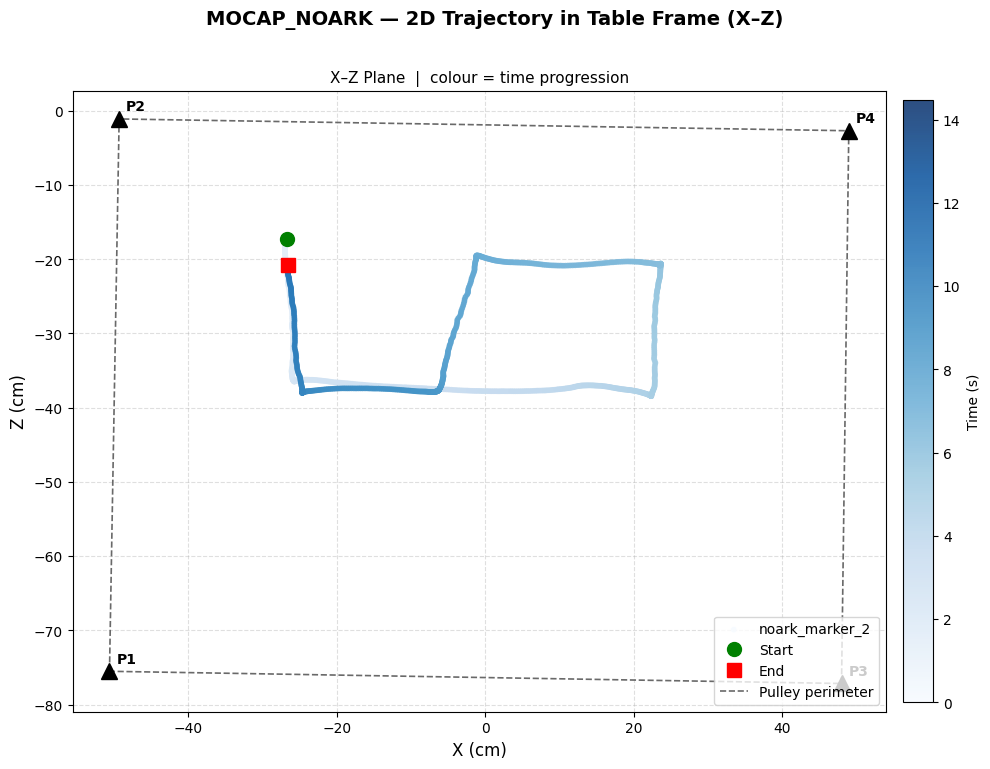

X range : nan → nan cm
Z range : nan → nan cm
Frames  : 1448  |  Duration: 14.47 s


In [16]:
# Cell 16
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df_n = tframe_dfs['noark_in_tframe'].copy()
df_t = tframe_dfs['table_in_tframe'].copy()

# ── noark_marker_2 X and Z in cm ─────────────────────────────────────────────
x_cam_cm = df_n['noark_m2_tf_x_m'].values * 100.0
z_cam_cm = df_n['noark_m2_tf_z_m'].values * 100.0
t_sec    = df_n['seconds'].values

# ── Pulley reference points (mean positions) ──────────────────────────────────
# table_Marker2=P1, table_Marker6=P2, table_Marker1=P3, table_Marker4=P4
PULLEY_MAP = {'P1': 2, 'P2': 6, 'P3': 1, 'P4': 4}
pulley_pos = {}
for label, mid in PULLEY_MAP.items():
    xc = f'table_m{mid}_tf_x_m'
    zc = f'table_m{mid}_tf_z_m'
    if xc in df_t.columns and zc in df_t.columns:
        pulley_pos[label] = (
            df_t[xc].mean() * 100.0,
            df_t[zc].mean() * 100.0,
        )

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('MOCAP_NOARK — 2D Trajectory in Table Frame (X–Z)',
             fontsize=14, fontweight='bold')

# Trajectory scatter coloured by time
sc = ax.scatter(
    x_cam_cm, z_cam_cm,
    c=t_sec, cmap='Blues',
    s=10, alpha=0.85,
    label='noark_marker_2',
    zorder=3,
)
cbar = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.035)
cbar.set_label('Time (s)', fontsize=10)

# Start and end markers
ax.plot(x_cam_cm[0],  z_cam_cm[0],  'go', ms=10, zorder=5, label='Start')
ax.plot(x_cam_cm[-1], z_cam_cm[-1], 'rs', ms=10, zorder=5, label='End')

# Pulley reference points
for lbl, (px, pz) in pulley_pos.items():
    ax.plot(px, pz, 'k^', ms=11, zorder=4)
    ax.annotate(lbl, (px, pz),
                xytext=(5, 6), textcoords='offset points',
                fontsize=10, fontweight='bold', color='black')

# Pulley perimeter outline
porder = ['P1', 'P2', 'P4', 'P3']
pcoords = [pulley_pos[p] for p in porder if p in pulley_pos]
if len(pcoords) == 4:
    pcoords_closed = pcoords + [pcoords[0]]
    ax.plot([p[0] for p in pcoords_closed],
            [p[1] for p in pcoords_closed],
            color='dimgray', lw=1.2, ls='--', zorder=2, label='Pulley perimeter')

ax.set_xlabel('X (cm)', fontsize=12)
ax.set_ylabel('Z (cm)', fontsize=12)
ax.set_title('X–Z Plane  |  colour = time progression', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_aspect('equal', adjustable='box')
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig('noark_m2_xz_trajectory_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'X range : {x_cam_cm.min():.2f} → {x_cam_cm.max():.2f} cm')
print(f'Z range : {z_cam_cm.min():.2f} → {z_cam_cm.max():.2f} cm')
print(f'Frames  : {len(t_sec)}  |  Duration: {t_sec[-1]-t_sec[0]:.2f} s')

## LOAD CAMERA DATA AND ENCODER DATA

In [ ]:
# Cell 17
# 2. Update File paths using the / operator (cross-platform)
CAM_CSV = repo_root/"recordings"/ "linear_t2" / "camera_data.csv"
ENC_CSV = repo_root / "recordings" / "linear_t2" / "sensor_data.csv"
print(f"Repo Root: {repo_root}")
# 3. Update Calibration paths to be relative to repo_root
CAM_CALIB_PATH   = repo_root / "notebooks" / "calibration" / "output" / "good.toml"
TABLE_CALIB_PATH = repo_root / "estimator" / "charuco_pose" / "charuco_pose.toml"

# ── Kinematics constants (from nkin.py) ──────────────────────────────────────
P2 = np.array([-0.495, 0, -0.027])   # Left upper pulley
P4 = np.array([ 0.495, 0, -0.027])   # Right upper pulley

r_ML = r_MR = 0.033   # Motor spool radius (m)

# ── Marker config (from camera_pose.py) ──────────────────────────────────────
MARKER_LENGTH = 0.049  # metres
MARKER_IDS    = [12, 14, 20]
MARKER_OFFSETS = {
    12: np.array([0,      0,  -0.055]),
    14: np.array([-0.126, 0,  -0.054]),
    20: np.array([ 0.126, 0,  -0.054]),
}

print("Config loaded ✓")

Repo Root: e:\Ragav\MS Bio Engineering\NOARK_backbone
Config loaded ✓


## LOAD CSV'S

In [18]:
# Cell 18
# ── Camera CSV ────────────────────────────────────────────────────────────────
cam_df = pd.read_csv(CAM_CSV, parse_dates=["timestamp"])
print(f"Camera CSV: {len(cam_df)} rows")
cam_df.head(3)

Camera CSV: 1132 rows


,timestamp,sync_pin,tvec_12_x,tvec_12_y,tvec_12_z,tvec_14_x,tvec_14_y,tvec_14_z,tvec_20_x,tvec_20_y,tvec_20_z,rvec_12_x,rvec_12_y,rvec_12_z,rvec_14_x,rvec_14_y,rvec_14_z,rvec_20_x,rvec_20_y,rvec_20_z
0,2026-04-23 11:49:39.157110,0,0.240277,-0.045530,0.432007,NaN,NaN,NaN,NaN,NaN,NaN,-3.113738,0.007525,-0.094086,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-23 11:49:39.195178,0,0.240229,-0.045525,0.431928,NaN,NaN,NaN,NaN,NaN,NaN,-3.115932,0.007867,-0.096541,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-23 11:49:39.236591,0,0.240262,-0.045527,0.431954,NaN,NaN,NaN,NaN,NaN,NaN,-3.115230,0.007747,-0.095778,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Cell 19
# ── Encoder CSV ───────────────────────────────────────────────────────────────
enc_df = pd.read_csv(ENC_CSV, parse_dates=["timestamp"])
print(f"Encoder CSV: {len(enc_df)} rows")
enc_df.head(3)

Encoder CSV: 11539 rows


,timestamp,Millis,enc1,enc2
0,2026-04-23 11:49:39.127084,20997.77,0.02,-0.01
1,2026-04-23 11:49:39.129123,20999.80,0.02,-0.01
2,2026-04-23 11:49:39.131125,21001.80,0.02,-0.01


In [20]:
# Cell 20
# ── Find sync pin rising edge — first row where sync_pin transitions to 1 ────
assert 'sync_pin' in cam_df.columns, f"sync_pin column not found. Columns: {cam_df.columns.tolist()}"

sync_rows = cam_df[cam_df['sync_pin'] == 1]
assert len(sync_rows) > 0, "sync_pin never goes HIGH — check your hardware/CSV"

# Rising edge = first row where sync_pin == 1
sync_idx       = sync_rows.index[0]
sync_timestamp = pd.Timestamp(cam_df.loc[sync_idx, 'timestamp'])

print(f"Sync pin rising edge at row : {sync_idx}")
print(f"Sync timestamp (wall-clock) : {sync_timestamp}")
print(f"Rows before sync (discarded): {sync_idx}")
print(f"Rows from sync onward       : {len(cam_df) - sync_idx}")

# Optional: inspect a few rows around the rising edge
print("\nRows around sync edge:")
print(cam_df[['timestamp', 'sync_pin']].iloc[max(0, sync_idx-2) : sync_idx+4].to_string())

Sync pin rising edge at row : 335
Sync timestamp (wall-clock) : 2026-04-23 11:49:46.275037
Rows before sync (discarded): 335
Rows from sync onward       : 797

Rows around sync edge:
                     timestamp  sync_pin
333 2026-04-23 11:49:46.238503         0
334 2026-04-23 11:49:46.256771         0
335 2026-04-23 11:49:46.275037         1
336 2026-04-23 11:49:46.293351         1
337 2026-04-23 11:49:46.311319         1
338 2026-04-23 11:49:46.330785         1


Sync column      : 'sync_pin'
Unique values    : [0 1]
Trigger edges    : 1
First trigger at : 7.118 s
Last  trigger at : 7.118 s


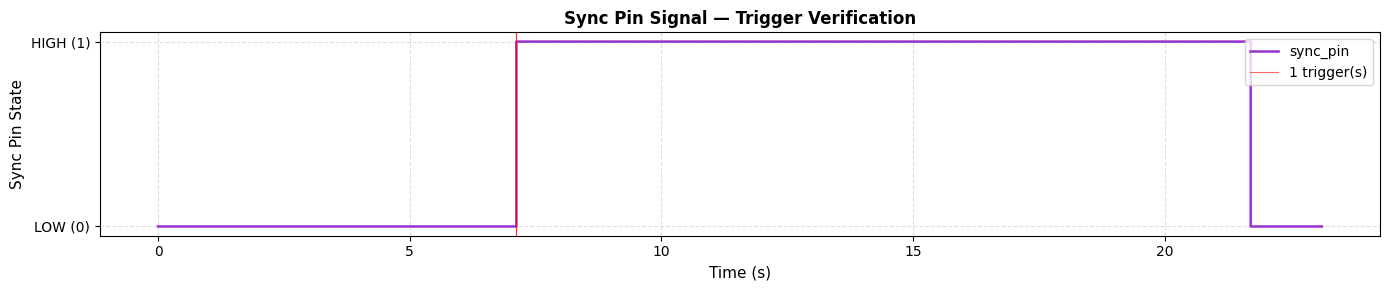

In [21]:
# Cell 21
# ── Sync Pin Verification ─────────────────────────────────────────────────────
# Plots the sync pin channel from encoder CSV to confirm trigger was received.
# Expects a column named 'sync' (or 'sync_pin') in cam_df.

SYNC_COL = next((c for c in cam_df.columns if 'sync' in c.lower()), None)

if SYNC_COL is None:
    print(f" No sync column found. Available columns: {cam_df.columns.tolist()}")
else:
    # Convert to numeric, coerce any non-numeric to NaN
    sync_signal = pd.to_numeric(cam_df[SYNC_COL], errors='coerce').values
    sync_time   = (cam_df['timestamp'] - cam_df['timestamp'].iloc[0]).dt.total_seconds().values

    # Detect edges (LOW→HIGH transitions = trigger events)
    trigger_indices = np.where(np.diff(sync_signal.astype(float)) > 0)[0] + 1
    print(f"Sync column      : '{SYNC_COL}'")
    print(f"Unique values    : {np.unique(sync_signal[~np.isnan(sync_signal)])}")
    print(f"Trigger edges    : {len(trigger_indices)}")
    if len(trigger_indices):
        print(f"First trigger at : {sync_time[trigger_indices[0]]:.3f} s")
        print(f"Last  trigger at : {sync_time[trigger_indices[-1]]:.3f} s")

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.step(sync_time, sync_signal, where='post', color='darkorchid', lw=1.8, label=SYNC_COL)

    # Mark each trigger edge
    for idx in trigger_indices:
        ax.axvline(sync_time[idx], color='red', lw=0.8, alpha=0.6)
    if len(trigger_indices):
        ax.axvline(sync_time[trigger_indices[0]], color='red', lw=0.8, alpha=0.6,
                   label=f'{len(trigger_indices)} trigger(s)')

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Sync Pin State', fontsize=11)
    ax.set_title('Sync Pin Signal — Trigger Verification', fontsize=12, fontweight='bold')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['LOW (0)', 'HIGH (1)'])
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('sync_pin_verification.png', dpi=150, bbox_inches='tight')
    plt.show()

## LOAD CAMERA CALIBRATION AND BUILD HELPERS

In [22]:
# Cell 22
# ── Load table reference frame only ──────────────────────────────────────────
tbl     = toml.load(TABLE_CALIB_PATH)
R_table = np.array(tbl["rotation_matrix"]).reshape(3, 3)
T_table = np.array(tbl["tvec"]).reshape(3, 1)

# Sanity checks
assert R_table.shape == (3, 3), f"R_table wrong shape: {R_table.shape}"
assert T_table.shape == (3, 1), f"T_table wrong shape: {T_table.shape}"

print("Table rotation R:")
print(np.round(R_table, 4))
print("\nTable translation T (m):", T_table.flatten().round(4))
print("\nShapes OK ✓")

Table rotation R:
[[-0.9995  0.0118 -0.0301]
 [-0.0117 -0.9999 -0.0028]
 [-0.0301 -0.0024  0.9995]]

Table translation T (m): [-0.0232 -0.0173  0.6735]

Shapes OK ✓


## Reconstruct NOARK Position from Camera Data

For each frame we:
1. Take the raw `tvec` / `rvec` for each detected marker (already stored by `Cam_Data_log.py`)
2. Apply the marker-specific physical offset to get the handle position in camera frame
3. Average all available marker positions → **centroid in camera frame**
4. Transform to **table frame**: `P_table = R_table.T @ (P_cam - T_table)`

In [23]:
# Cell 23
# ── Data sanity check ─────────────────────────────────────────────────────────
print("Shape:", cam_df.shape)

print("\n--- NaN counts per marker ---")
for mid in [12, 14, 20]:
    col = f'tvec_{mid}_x'
    print(f"Marker {mid} NaN rows: {cam_df[col].isna().sum()} / {len(cam_df)}")

print("\n--- Rows where ALL 3 markers missing ---")
all_missing = cam_df[['tvec_12_x','tvec_14_x','tvec_20_x']].isna().all(axis=1)
print(f"Count: {all_missing.sum()}")

print("\n--- Rows where ANY marker missing ---")
any_missing = cam_df[['tvec_12_x','tvec_14_x','tvec_20_x']].isna().any(axis=1)
print(f"Count: {any_missing.sum()}")

print("\n--- Sample of raw tvec values (first 10 rows) ---")
print(cam_df[['timestamp','tvec_12_x','tvec_14_x','tvec_20_x']].head(10).to_string())

Shape: (1132, 20)

--- NaN counts per marker ---
Marker 12 NaN rows: 66 / 1132
Marker 14 NaN rows: 1085 / 1132
Marker 20 NaN rows: 1042 / 1132

--- Rows where ALL 3 markers missing ---
Count: 20

--- Rows where ANY marker missing ---
Count: 1132

--- Sample of raw tvec values (first 10 rows) ---
                   timestamp  tvec_12_x  tvec_14_x  tvec_20_x
0 2026-04-23 11:49:39.157110   0.240277        NaN        NaN
1 2026-04-23 11:49:39.195178   0.240229        NaN        NaN
2 2026-04-23 11:49:39.236591   0.240262        NaN        NaN
3 2026-04-23 11:49:39.276659   0.240299        NaN        NaN
4 2026-04-23 11:49:39.309794   0.240279        NaN        NaN
5 2026-04-23 11:49:39.337165   0.240298        NaN        NaN
6 2026-04-23 11:49:39.359539   0.240369        NaN        NaN
7 2026-04-23 11:49:39.380700   0.240335        NaN        NaN
8 2026-04-23 11:49:39.403558   0.240369        NaN        NaN
9 2026-04-23 11:49:39.424920   0.240343        NaN        NaN


In [24]:
# Cell 24
def get_centroid_cam(row, marker_ids=MARKER_IDS, offsets=MARKER_OFFSETS):
    """
    Replicates camera_pose.py::_get_centroid().
    Returns centroid in CAMERA frame as (3,1), or None if no marker visible.
    """
    points = []
    for mid in marker_ids:
        tvec_cols = [f"tvec_{mid}_x", f"tvec_{mid}_y", f"tvec_{mid}_z"]
        rvec_cols = [f"rvec_{mid}_x", f"rvec_{mid}_y", f"rvec_{mid}_z"]
        tvec = row[tvec_cols].values.astype(float)
        rvec = row[rvec_cols].values.astype(float)
        if np.any(np.isnan(tvec)) or np.any(np.isnan(rvec)):
            continue
        R_marker, _ = cv2.Rodrigues(rvec)
        offset = offsets[mid].reshape(3, 1)
        pos_cam = R_marker @ offset + tvec.reshape(3, 1)
        points.append(pos_cam.flatten())
    if not points:
        return None
    return np.mean(points, axis=0).reshape(3, 1)


def cam_to_table(p_cam, R_table=R_table, T_table=T_table):
    """
    Replicates camera_pose.py::_get_local_coordinates().
    P_table = R_table.T @ (P_cam - T_table)
    """
    return (R_table.T @ (p_cam - T_table)).flatten()


# Apply row-wise
results = []
for _, row in cam_df.iterrows():
    p_cam = get_centroid_cam(row)
    if p_cam is None:
        results.append([np.nan, np.nan, np.nan])
    else:
        results.append(cam_to_table(p_cam))

pos_cam = pd.DataFrame(results, columns=["x_cam", "y_cam", "z_cam"])
cam_df  = pd.concat([cam_df.reset_index(drop=True), pos_cam], axis=1)

## Reconstruct NOARK Position from Encoder Data

Replicates the kinematics in `nkin.py`:
1. At the **zero event** (first encoder row), capture camera-derived free lengths `P2_to_NOARK_init` and `P4_to_NOARK_init`
2. For each encoder tick: `L_free_L = init_L + r_ML * deg2rad(enc1)`, `L_free_R = init_R - r_MR * deg2rad(enc2)`
3. Solve **circle–circle intersection** between `P2` (radius `L_free_L`) and `P4` (radius `L_free_R`) to get `(x, z)` in table frame

In [25]:
# Cell 25
#  Find the zero-reference camera position ─────────────────────────
init_row = cam_df.iloc[0]  # first camera frame — no dropna needed
N0 = np.array([init_row["x_cam"], 0, init_row["z_cam"]])
print(N0)
P2_to_NOARK_init = sqrt((N0[0] - P2[0])**2 + (N0[2] - P2[2])**2)  # P2 is left pulley, camera data
P4_to_NOARK_init = sqrt((N0[0] - P4[0])**2 + (N0[2] - P4[2])**2)  # P4 is right pulley, camera data

print(f"Init position (table frame)_camera_data:  x={N0[0]*100:.2f} cm   z={N0[2]*100:.2f} cm")
print(f"P2_to_NOARK_init: {P2_to_NOARK_init*100:.2f} cm")
print(f"P4_to_NOARK_init: {P4_to_NOARK_init*100:.2f} cm")

[-0.2541034  0.        -0.1942413]
Init position (table frame)_camera_data:  x=-25.41 cm   z=-19.42 cm
P2_to_NOARK_init: 29.33 cm
P4_to_NOARK_init: 76.75 cm


In [26]:
# Cell 26
#  Circle-circle intersection (ENCODER) ────────────────────────────────

def circle_intersect_xz(p2, p4, r_l, r_r):
    """
    Finds the intersection of two circles in the X-Z plane.
    p2, p4 : 3-element arrays, only [0] (X) and [2] (Z) are used
    r_l    : radius of circle centred at p2  (left cable free length)
    r_r    : radius of circle centred at p4  (right cable free length)
    Returns (x, z) of the 'upper' solution (enc_1 in nkin.py), or (nan, nan).
    """
    x2, z2 = p2[0], p2[2]
    x4, z4 = p4[0], p4[2]
    d = sqrt((x4 - x2)**2 + (z4 - z2)**2)

    # Triangle feasibility check
    if d > r_l + r_r or d < abs(r_l - r_r) or d == 0:
        return np.nan, np.nan

    a  = (r_l**2 - r_r**2 + d**2) / (2 * d)
    h2 = r_l**2 - a**2
    if h2 < 0:
        return np.nan, np.nan
    h = sqrt(h2)

    xm = x2 + a * (x4 - x2) / d
    zm = z2 + a * (z4 - z2) / d

    # 'enc_1' solution — matches nkin.py x_enc_1 / z_enc_1
    x_sol = xm + h * (z4 - z2) / d
    z_sol = zm - h * (x4 - x2) / d
    return x_sol, z_sol


# ── Step 4c: Compute encoder-based positions ──────────────────────────────────
x_enc_list, z_enc_list = [], []

for _, row in enc_df.iterrows():
    delta_L = r_ML * np.deg2rad(float(row["enc1"]))
    delta_R = r_MR * np.deg2rad(float(row["enc2"]))

    L_free_L = P2_to_NOARK_init + delta_L
    L_free_R = P4_to_NOARK_init - delta_R

    x_e, z_e = circle_intersect_xz(P2, P4, L_free_L, L_free_R)
    x_enc_list.append(x_e)
    z_enc_list.append(z_e)

enc_df["x_enc"] = x_enc_list
enc_df["z_enc"] = z_enc_list

print(f"Valid encoder frames: {enc_df['x_enc'].notna().sum()} / {len(enc_df)}")
enc_df[["timestamp", "enc1", "enc2", "x_enc", "z_enc"]].head(5).round(4)

Valid encoder frames: 11539 / 11539


,timestamp,enc1,enc2,x_enc,z_enc
0,2026-04-23 11:49:39.127084,0.02,-0.01,-0.2541,-0.1943
1,2026-04-23 11:49:39.129123,0.02,-0.01,-0.2541,-0.1943
2,2026-04-23 11:49:39.131125,0.02,-0.01,-0.2541,-0.1943
3,2026-04-23 11:49:39.133068,0.02,-0.01,-0.2541,-0.1943
4,2026-04-23 11:49:39.135108,0.02,-0.01,-0.2541,-0.1943


## Time-Align Camera and Encoder Signals

Both CSVs use wall-clock timestamps. We align them by interpolating encoder onto the camera time grid.

In [27]:
# Cell 27
# ── Use sync pin timestamp as the single common t0 for all signals ────────────
cam_df['timestamp'] = pd.to_datetime(cam_df['timestamp'])
enc_df['timestamp'] = pd.to_datetime(enc_df['timestamp'])

# t0 is now the hardware sync moment — not an arbitrary CSV start
t0 = sync_timestamp

cam_df['t_sec'] = (cam_df['timestamp'] - t0).dt.total_seconds()
enc_df['t_sec'] = (enc_df['timestamp'] - t0).dt.total_seconds()

# Keep only rows from sync onward (t_sec >= 0) for camera
# Encoder rows before sync are kept — they define the init cable lengths
cam_sync = cam_df[cam_df['t_sec'] >= 0].sort_values('t_sec').reset_index(drop=True)
enc_s    = enc_df.sort_values('t_sec').reset_index(drop=True)

print(f"Camera frames before sync (dropped) : {(cam_df['t_sec'] < 0).sum()}")
print(f"Camera frames from sync onward      : {len(cam_sync)}")
print(f"Encoder frames total                : {len(enc_s)}")
print(f"t_sec=0 is now the sync pin moment  : {sync_timestamp}")

interp_x = interp1d(enc_s['t_sec'], enc_s['x_enc'],
                    kind='linear', bounds_error=False, fill_value=np.nan)
interp_z = interp1d(enc_s['t_sec'], enc_s['z_enc'],
                    kind='linear', bounds_error=False, fill_value=np.nan)

merged = cam_sync.copy()
merged['x_enc'] = interp_x(merged['t_sec'])
merged['z_enc'] = interp_z(merged['t_sec'])

for col in ['x_cam', 'z_cam', 'x_enc', 'z_enc']:
    merged[col + '_cm'] = merged[col] * 100

print(f"\nTotal merged frames  : {len(merged)}")
print(f"Valid cam frames     : {merged['x_cam'].notna().sum()}")
merged[['t_sec', 'x_cam_cm', 'z_cam_cm', 'x_enc_cm', 'z_enc_cm']].head(5).round(3)

Camera frames before sync (dropped) : 335
Camera frames from sync onward      : 797
Encoder frames total                : 11539
t_sec=0 is now the sync pin moment  : 2026-04-23 11:49:46.275037

Total merged frames  : 797
Valid cam frames     : 777


,t_sec,x_cam_cm,z_cam_cm,x_enc_cm,z_enc_cm
0,0.000,-25.410,-19.393,-25.412,-19.414
1,0.018,-25.425,-19.378,-25.414,-19.416
2,0.036,-25.424,-19.376,-25.412,-19.414
3,0.056,-25.422,-19.378,-25.414,-19.416
4,0.074,-25.433,-19.364,-25.412,-19.414


# ── Mocap time alignment using sync pin ───────────────────────────────────────
# noark_st_time = wall-clock time when Motive started saving (triggered by sync pin)
# sync_timestamp = wall-clock time of the sync pin rising edge in camera CSV
# These should be nearly identical — offset_sec should be close to 0

In [40]:
# Cell 28
# ── Step 1: Extract mocap position arrays in cm ───────────────────────────────
df_mocap = tframe_dfs['noark_in_tframe'].copy()

# Drop NaN rows before interpolation — interp1d cannot handle NaN in input
_mask   = df_mocap['noark_m2_tf_x_m'].notna() & df_mocap['noark_m2_tf_z_m'].notna()
mocap_t = df_mocap.loc[_mask, 'seconds'].values
mocap_x = df_mocap.loc[_mask, 'noark_m2_tf_x_m'].values * 100.0
mocap_z = df_mocap.loc[_mask, 'noark_m2_tf_z_m'].values * 100.0

print(f"Mocap frames : {len(mocap_t)}  (from {len(df_mocap)} total, {len(df_mocap)-len(mocap_t)} NaN rows dropped)")
print(f"Mocap X range: {mocap_x.min():.2f} → {mocap_x.max():.2f} cm")
print(f"Mocap Z range: {mocap_z.min():.2f} → {mocap_z.max():.2f} cm")

# ── Step 2: Wall-clock offset ─────────────────────────────────────────────────
mocap_wall_t0 = pd.Timestamp(noark_st_time)
cam_enc_t0    = pd.Timestamp(t0)
offset_sec    = (mocap_wall_t0 - cam_enc_t0).total_seconds()

print(f"\nMocap wall-clock t0      : {mocap_wall_t0}")
print(f"Cam/enc t0               : {cam_enc_t0}")
print(f"Offset (mocap - cam/enc) : {offset_sec:.3f} s")

# ── Step 3: First-pass interpolation ──────────────────────────────────────────
mocap_t_aligned = mocap_t + offset_sec

interp_mocap_x = interp1d(mocap_t_aligned, mocap_x,
                           kind='linear', bounds_error=False, fill_value=np.nan)
interp_mocap_z = interp1d(mocap_t_aligned, mocap_z,
                           kind='linear', bounds_error=False, fill_value=np.nan)

merged['x_mocap_cm'] = interp_mocap_x(merged['t_sec'])
merged['z_mocap_cm'] = interp_mocap_z(merged['t_sec'])

# ── Step 4: Cross-correlation on valid frames only (no filling) ───────────────
from scipy.signal import correlate

mask_cc    = merged['x_cam_cm'].notna() & merged['x_mocap_cm'].notna()
cam_x_cc   = merged['x_cam_cm'][mask_cc].values
mocap_x_cc = merged['x_mocap_cm'][mask_cc].values

corr     = correlate(cam_x_cc, mocap_x_cc, mode='full')
lags     = np.arange(-(len(mocap_x_cc)-1), len(cam_x_cc))
best_lag = lags[np.argmax(corr)]
dt       = merged['t_sec'][mask_cc].diff().median()
lag_sec  = best_lag * dt

print(f"\nResidual lag  : {lag_sec:.3f} s  (positive = camera leads mocap)")
print(f"Final offset  : {offset_sec + lag_sec:.3f} s")

# ── Step 5: Re-interpolate with corrected offset ──────────────────────────────
mocap_t_aligned = mocap_t + offset_sec + lag_sec

interp_mocap_x = interp1d(mocap_t_aligned, mocap_x,
                           kind='linear', bounds_error=False, fill_value=np.nan)
interp_mocap_z = interp1d(mocap_t_aligned, mocap_z,
                           kind='linear', bounds_error=False, fill_value=np.nan)

merged['x_mocap_cm'] = interp_mocap_x(merged['t_sec'])
merged['z_mocap_cm'] = interp_mocap_z(merged['t_sec'])
valid_mocap = merged['x_mocap_cm'].notna().sum()
print(f"\nValid mocap frames after correction: {valid_mocap} / {len(merged)}")

overlap = min(mocap_t_aligned[-1], merged['t_sec'].iloc[-1]) - \
          max(mocap_t_aligned[0],  merged['t_sec'].iloc[0])
print(f"Overlap : {overlap:.3f} s  {'✓ OK' if overlap > 1.0 else '✗ BAD — check offset sign!'}")

merged[['t_sec', 'x_cam_cm', 'z_cam_cm', 'x_enc_cm', 'z_enc_cm',
        'x_mocap_cm', 'z_mocap_cm']].head(5).round(3)

print(tframe_dfs['noark_in_tframe'].columns.tolist())
print(tframe_dfs['noark_in_tframe'].head(3))

Mocap frames : 1447  (from 1448 total, 1 NaN rows dropped)
Mocap X range: -27.01 → 23.63 cm
Mocap Z range: -38.44 → -17.25 cm

Mocap wall-clock t0      : 2026-04-23 11:49:48.118000
Cam/enc t0               : 2026-04-23 11:49:46.275037
Offset (mocap - cam/enc) : 1.843 s

Residual lag  : -1.280 s  (positive = camera leads mocap)
Final offset  : 0.563 s

Valid mocap frames after correction: 719 / 797
Overlap : 14.470 s  ✓ OK
['frame', 'seconds', 'time', 'noark_m2_tf_x_m', 'noark_m2_tf_y_m', 'noark_m2_tf_z_m']
   frame  seconds                    time  noark_m2_tf_x_m  noark_m2_tf_y_m  \
0      0     0.00 2026-04-23 11:49:48.118        -0.267934         0.196630   
1      1     0.01 2026-04-23 11:49:48.128        -0.267928         0.196658   
2      2     0.02 2026-04-23 11:49:48.138              NaN              NaN   

   noark_m2_tf_z_m  
0        -0.172542  
1        -0.172530  
2              NaN  


## ALIGNMENT SANITY CHECK

If mocap and camera traces are horizontally offset (time-shifted), `offset_sec` is wrong and all error stats will be meaningless. Fix by adjusting the offset manually until traces overlap.

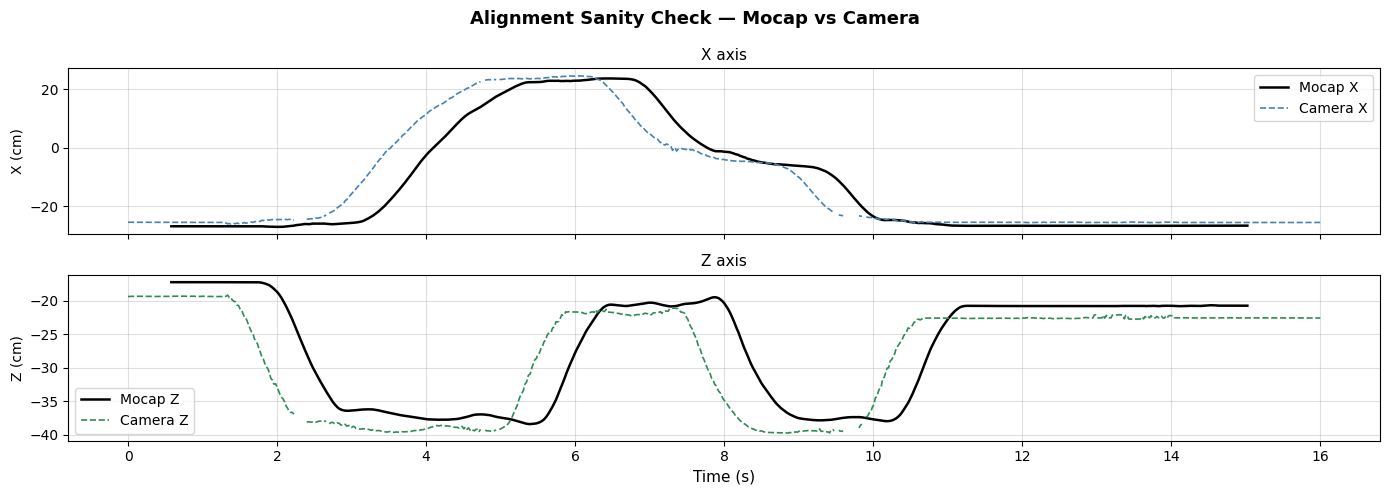

If the two traces are time-shifted, adjust offset_sec in the cell above until they overlap.


In [41]:
# Cell 30
# ── Quick alignment sanity check — mocap should overlap with camera ───────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle('Alignment Sanity Check — Mocap vs Camera', fontsize=13, fontweight='bold')

axes[0].plot(merged['t_sec'], merged['x_mocap_cm'], color='black',    lw=1.8, label='Mocap X')
axes[0].plot(merged['t_sec'], merged['x_cam_cm'],   color='steelblue', lw=1.2, ls='--', label='Camera X')
axes[0].legend(fontsize=10); axes[0].set_title('X axis', fontsize=11)
axes[0].grid(True, alpha=0.4); axes[0].set_ylabel('X (cm)', fontsize=10)

axes[1].plot(merged['t_sec'], merged['z_mocap_cm'], color='black',   lw=1.8, label='Mocap Z')
axes[1].plot(merged['t_sec'], merged['z_cam_cm'],   color='seagreen', lw=1.2, ls='--', label='Camera Z')
axes[1].legend(fontsize=10); axes[1].set_title('Z axis', fontsize=11)
axes[1].grid(True, alpha=0.4); axes[1].set_ylabel('Z (cm)', fontsize=10)
axes[1].set_xlabel('Time (s)', fontsize=11)

plt.tight_layout()
plt.show()
print("If the two traces are time-shifted, adjust offset_sec in the cell above until they overlap.")

## ERROR STATISTICS — Camera vs Encoder

In [43]:
# Cell 31
# ── Compute raw error columns ─────────────────────────────────────────────────
merged["err_x_cm"]  = merged["x_enc_cm"] - merged["x_cam_cm"]
merged["err_z_cm"]  = merged["z_enc_cm"] - merged["z_cam_cm"]
merged["err_2d_cm"] = np.sqrt(merged["err_x_cm"]**2 + merged["err_z_cm"]**2)

# ── Pull out as numpy arrays and strip NaNs ───────────────────────────────────
err_x  = merged["err_x_cm"].to_numpy()
err_z  = merged["err_z_cm"].to_numpy()
err_2d = merged["err_2d_cm"].to_numpy()

mask         = ~np.isnan(err_x) & ~np.isnan(err_z) & ~np.isnan(err_2d)
err_x_valid  = err_x[mask]
err_z_valid  = err_z[mask]
err_2d_valid = err_2d[mask]

# ── Stats helper ──────────────────────────────────────────────────────────────
def arr_stats(arr, name):
    print(f"{name:15s}  mean={arr.mean():.3f}  std={arr.std():.3f}  "
          f"min={arr.min():.3f}  max={arr.max():.3f}  "
          f"RMSE={np.sqrt((arr**2).mean()):.3f}  "
          f"95th={np.percentile(arr, 95):.3f}")

print(f"Valid frames for error: {mask.sum()} / {len(mask)}")
arr_stats(err_x_valid,  "err_x_cm")
arr_stats(err_z_valid,  "err_z_cm")
arr_stats(err_2d_valid, "err_2d_cm")

Valid frames for error: 777 / 797
err_x_cm         mean=0.210  std=0.363  min=-0.918  max=1.513  RMSE=0.419  95th=1.031
err_z_cm         mean=-0.415  std=0.392  min=-1.652  max=0.834  RMSE=0.571  95th=0.111
err_2d_cm        mean=0.612  std=0.357  min=0.013  max=1.652  RMSE=0.708  95th=1.271


## Plot 1: Time-Series Comparison — Camera vs Encoder

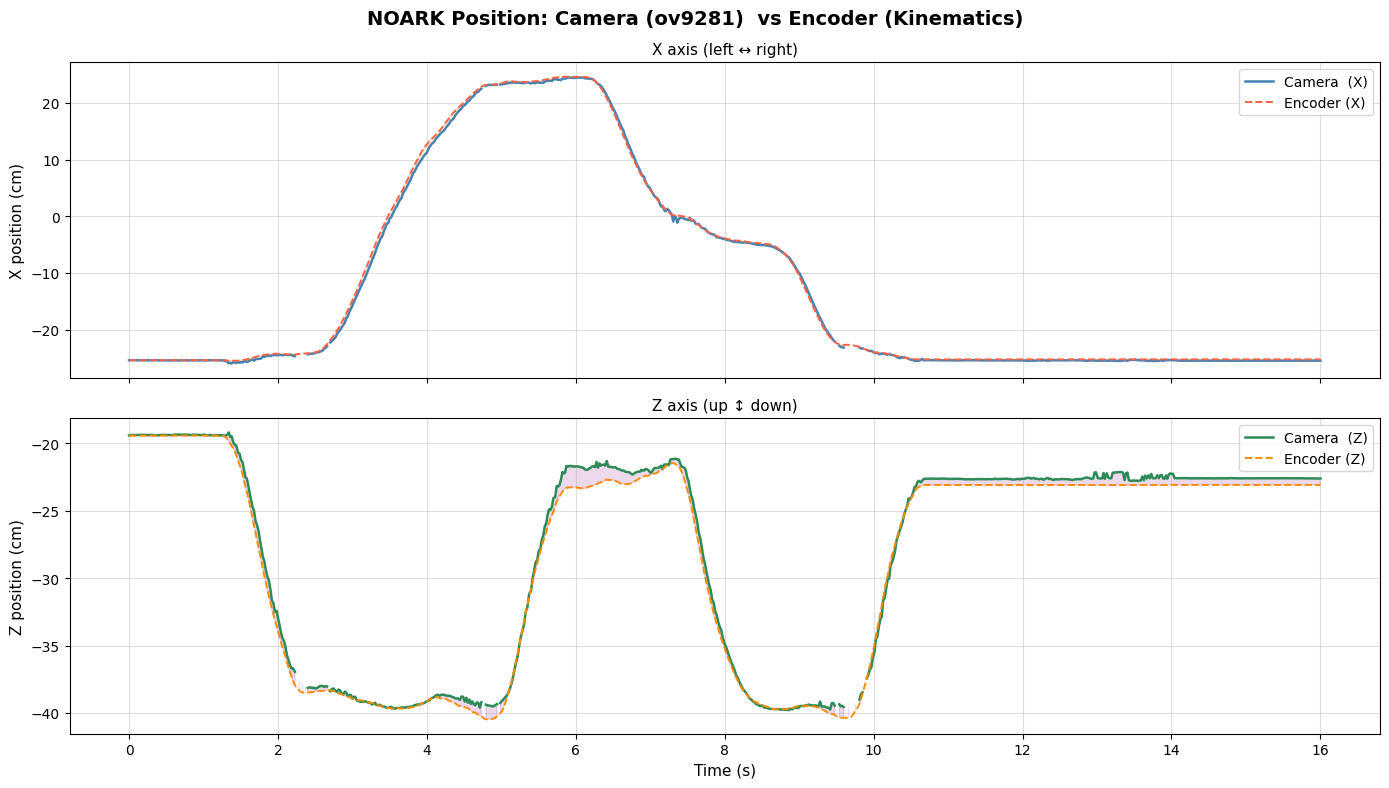

Saved: plot1_timeseries.png


In [44]:
# Cell 32
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NOARK Position: Camera (ov9281)  vs Encoder (Kinematics)", fontsize=14, fontweight='bold')

t = merged["t_sec"]

ax = axes[0]
ax.plot(t, merged["x_cam_cm"], color="steelblue",  lw=1.8, label="Camera  (X)")
ax.plot(t, merged["x_enc_cm"], color="tomato",     lw=1.4, ls="--", label="Encoder (X)")
ax.fill_between(t, merged["x_cam_cm"], merged["x_enc_cm"], alpha=0.15, color="orange")
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

ax = axes[1]
ax.plot(t, merged["z_cam_cm"], color="seagreen",   lw=1.8, label="Camera  (Z)")
ax.plot(t, merged["z_enc_cm"], color="darkorange", lw=1.4, ls="--", label="Encoder (Z)")
ax.fill_between(t, merged["z_cam_cm"], merged["z_enc_cm"], alpha=0.15, color="purple")
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

plt.tight_layout()
plt.savefig(repo_root / "vaideesh" / "Analysis" / "plot1_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_timeseries.png")

## Plot 2: 2D Trajectory + Error Box Plot — Camera vs Encoder

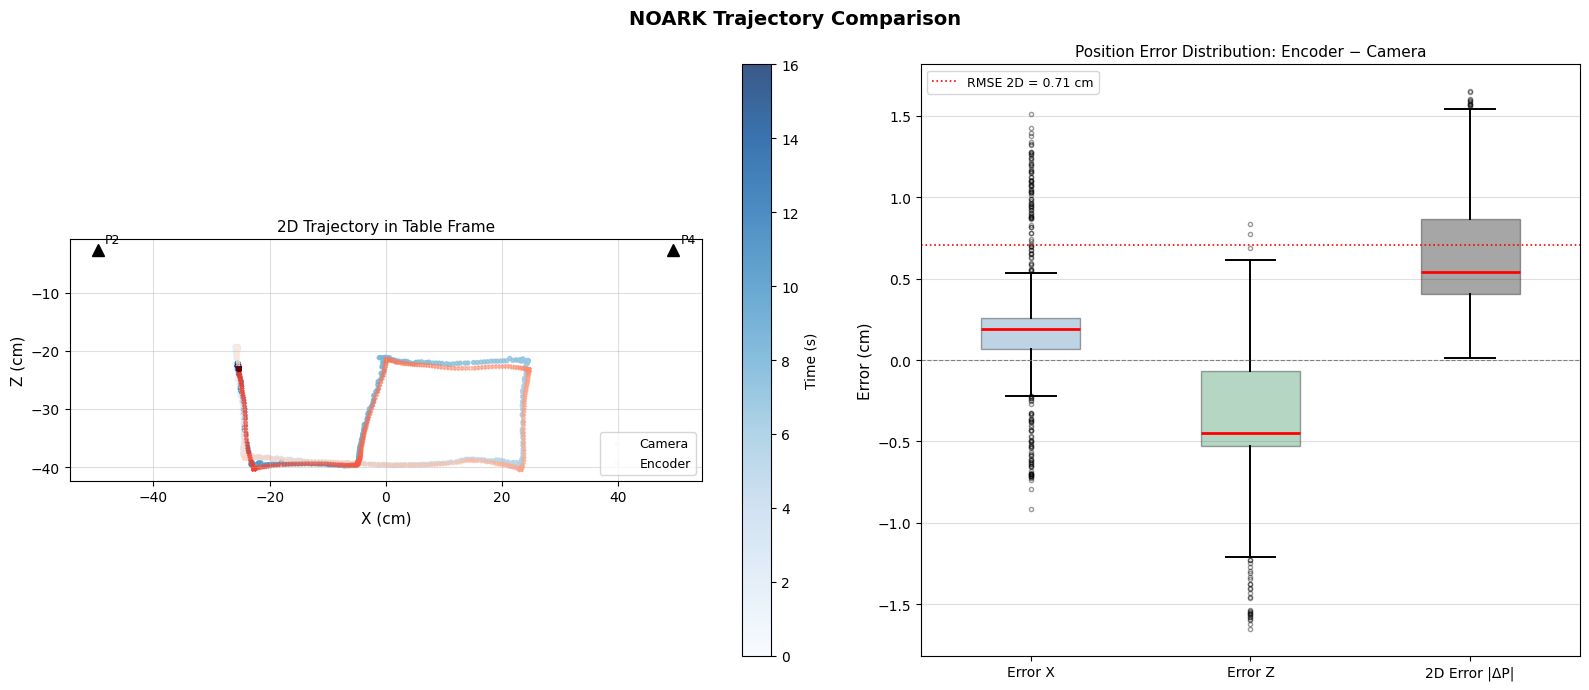

In [45]:
# Cell 33
fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle("NOARK Trajectory Comparison", fontsize=14, fontweight='bold')

# ── Left panel: 2D trajectory in X-Z table frame ─────────────────────────────
ax1 = fig.add_subplot(gs[0])
sc_cam = ax1.scatter(merged["x_cam_cm"], merged["z_cam_cm"],
                     c=merged["t_sec"], cmap="Blues", s=8, alpha=0.8, label="Camera")
sc_enc = ax1.scatter(merged["x_enc_cm"], merged["z_enc_cm"],
                     c=merged["t_sec"], cmap="Reds",  s=8, alpha=0.6, label="Encoder", marker="x")

for name, pt in [("P2", P2), ("P4", P4)]:
    ax1.plot(pt[0]*100, pt[2]*100, "k^", ms=8)
    ax1.annotate(name, (pt[0]*100, pt[2]*100), textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.colorbar(sc_cam, ax=ax1, label="Time (s)")
ax1.set_xlabel("X (cm)", fontsize=11)
ax1.set_ylabel("Z (cm)", fontsize=11)
ax1.set_title("2D Trajectory in Table Frame", fontsize=11)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.4)
ax1.set_aspect("equal", adjustable="box")

# ── Right panel: Box plot of position errors ──────────────────────────────────
ax2 = fig.add_subplot(gs[1])

error_data = [err_x_valid, err_z_valid, err_2d_valid]
labels      = ["Error X", "Error Z", "2D Error |ΔP|"]
colors      = ["steelblue", "seagreen", "black"]

bp = ax2.boxplot(
    error_data,
    labels=labels,
    patch_artist=True,
    notch=False,
    widths=0.45,
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.4),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

rmse_2d = np.sqrt((err_2d_valid**2).mean())
ax2.axhline(rmse_2d, color="red", lw=1.2, ls=":", label=f"RMSE 2D = {rmse_2d:.2f} cm")
ax2.axhline(0, color="grey", lw=0.8, ls="--")
ax2.set_ylabel("Error (cm)", fontsize=11)
ax2.set_title("Position Error Distribution: Encoder − Camera", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4, axis="y")

plt.tight_layout()
plt.savefig(repo_root / "vaideesh" / "Analysis" / "plot2_trajectory_error.png", dpi=150, bbox_inches="tight")
plt.show()

## ERROR STATISTICS — Mocap vs Camera

In [46]:
# Cell 34
# ── Mocap vs Camera errors ────────────────────────────────────────────────────
merged['err_mc_x_cm']  = merged['x_cam_cm']  - merged['x_mocap_cm']
merged['err_mc_z_cm']  = merged['z_cam_cm']  - merged['z_mocap_cm']
merged['err_mc_2d_cm'] = np.sqrt(merged['err_mc_x_cm']**2 + merged['err_mc_z_cm']**2)

mask_mc = (~merged['err_mc_x_cm'].isna() &
           ~merged['err_mc_z_cm'].isna() &
           ~merged['err_mc_2d_cm'].isna())

err_mc_x   = merged['err_mc_x_cm'][mask_mc].to_numpy()
err_mc_z   = merged['err_mc_z_cm'][mask_mc].to_numpy()
err_mc_2d  = merged['err_mc_2d_cm'][mask_mc].to_numpy()

print(f"Valid frames for Mocap vs Camera error: {mask_mc.sum()} / {len(merged)}")
arr_stats(err_mc_x,  "err_mc_x_cm")
arr_stats(err_mc_z,  "err_mc_z_cm")
arr_stats(err_mc_2d, "err_mc_2d_cm")

print(f"x_mocap_cm valid : {merged['x_mocap_cm'].notna().sum()}")
print(f"x_cam_cm   valid : {merged['x_cam_cm'].notna().sum()}")
print(f"Both valid       : {(merged['x_mocap_cm'].notna() & merged['x_cam_cm'].notna()).sum()}")

Valid frames for Mocap vs Camera error: 699 / 797
err_mc_x_cm      mean=1.004  std=6.195  min=-15.039  max=18.092  RMSE=6.275  95th=14.795
err_mc_z_cm      mean=-1.804  std=5.131  min=-14.898  max=12.034  RMSE=5.439  95th=9.546
err_mc_2d_cm     mean=6.722  std=4.877  min=0.314  max=18.337  RMSE=8.304  95th=15.140
x_mocap_cm valid : 719
x_cam_cm   valid : 777
Both valid       : 699


## ERROR STATISTICS — Mocap vs Encoder

In [47]:
# Cell 35
# ── Mocap vs Encoder errors ───────────────────────────────────────────────────
merged['err_me_x_cm']  = merged['x_enc_cm']  - merged['x_mocap_cm']
merged['err_me_z_cm']  = merged['z_enc_cm']  - merged['z_mocap_cm']
merged['err_me_2d_cm'] = np.sqrt(merged['err_me_x_cm']**2 + merged['err_me_z_cm']**2)

mask_me = (~merged['err_me_x_cm'].isna() &
           ~merged['err_me_z_cm'].isna() &
           ~merged['err_me_2d_cm'].isna())

err_me_x   = merged['err_me_x_cm'][mask_me].to_numpy()
err_me_z   = merged['err_me_z_cm'][mask_me].to_numpy()
err_me_2d  = merged['err_me_2d_cm'][mask_me].to_numpy()

print(f"Valid frames for Mocap vs Encoder error: {mask_me.sum()} / {len(merged)}")
arr_stats(err_me_x,  "err_me_x_cm")
arr_stats(err_me_z,  "err_me_z_cm")
arr_stats(err_me_2d, "err_me_2d_cm")

Valid frames for Mocap vs Encoder error: 719 / 797
err_me_x_cm      mean=1.118  std=6.517  min=-15.123  max=18.972  RMSE=6.612  95th=15.915
err_me_z_cm      mean=-2.296  std=5.146  min=-15.527  max=11.035  RMSE=5.635  95th=9.118
err_me_2d_cm     mean=7.144  std=4.944  min=0.556  max=19.205  RMSE=8.688  95th=16.165


## Plot 3: Time-Series — Mocap (GT) vs Camera

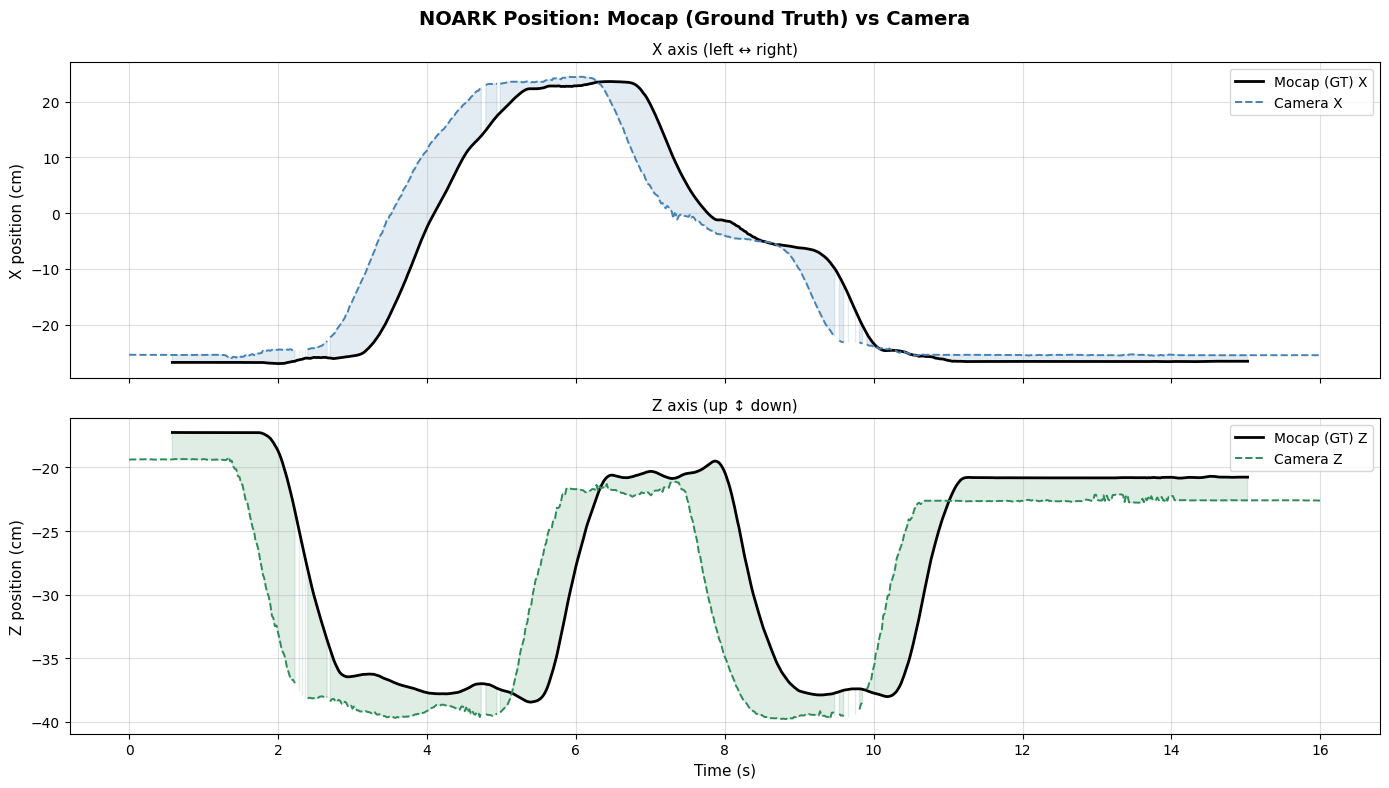

Saved: plot_mocap_vs_camera_timeseries.png


In [48]:
# Cell 36
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NOARK Position: Mocap (Ground Truth) vs Camera", fontsize=14, fontweight='bold')

t = merged['t_sec']

ax = axes[0]
ax.plot(t, merged['x_mocap_cm'], color='black',     lw=2.0, label='Mocap (GT) X')
ax.plot(t, merged['x_cam_cm'],   color='steelblue', lw=1.4, ls='--', label='Camera X')
ax.fill_between(t, merged['x_mocap_cm'], merged['x_cam_cm'], alpha=0.15, color='steelblue')
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

ax = axes[1]
ax.plot(t, merged['z_mocap_cm'], color='black',    lw=2.0, label='Mocap (GT) Z')
ax.plot(t, merged['z_cam_cm'],   color='seagreen', lw=1.4, ls='--', label='Camera Z')
ax.fill_between(t, merged['z_mocap_cm'], merged['z_cam_cm'], alpha=0.15, color='seagreen')
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

plt.tight_layout()
plt.savefig('plot_mocap_vs_camera_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_mocap_vs_camera_timeseries.png")

## Plot 4: Time-Series — Mocap (GT) vs Encoder

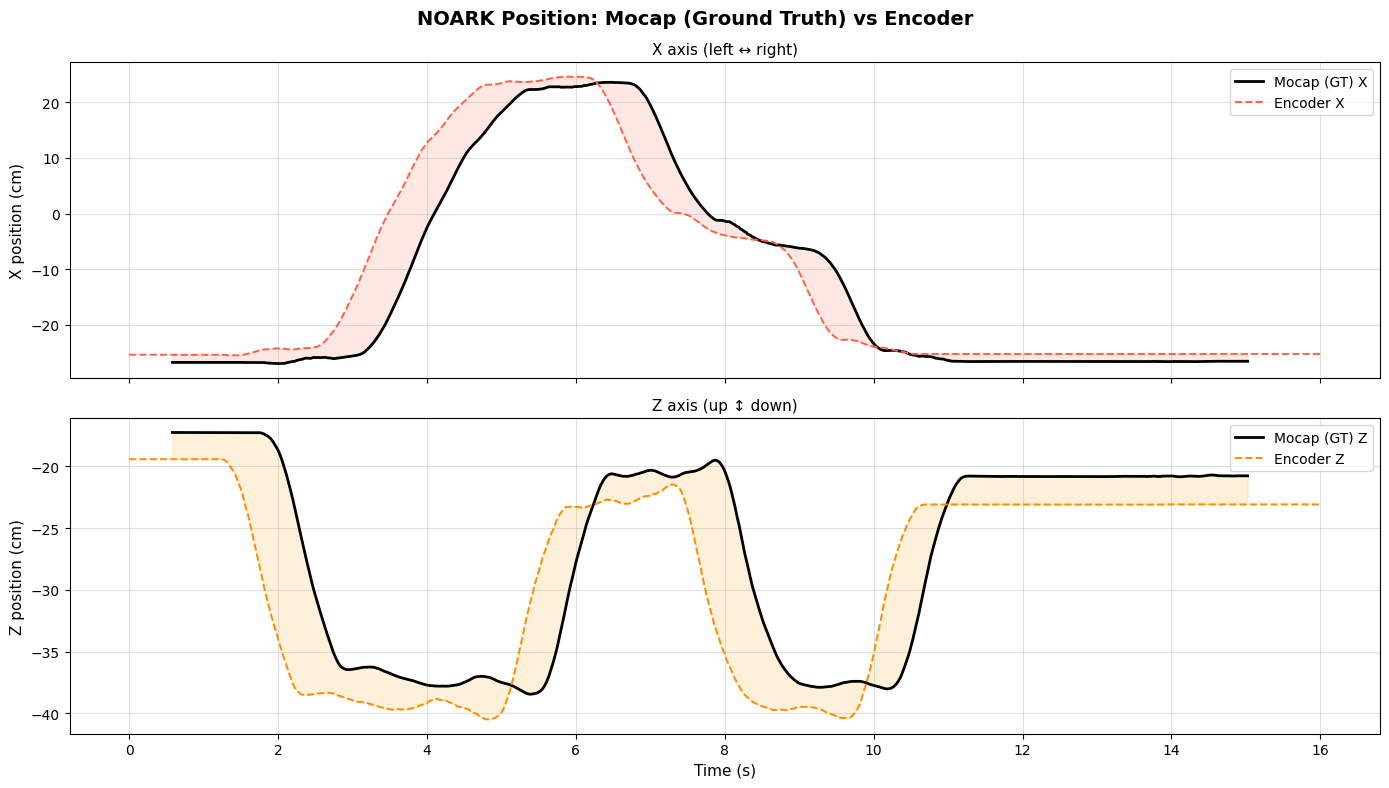

Saved: plot_mocap_vs_encoder_timeseries.png


In [49]:
# Cell 37
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NOARK Position: Mocap (Ground Truth) vs Encoder", fontsize=14, fontweight='bold')

t = merged['t_sec']

ax = axes[0]
ax.plot(t, merged['x_mocap_cm'], color='black',  lw=2.0, label='Mocap (GT) X')
ax.plot(t, merged['x_enc_cm'],   color='tomato', lw=1.4, ls='--', label='Encoder X')
ax.fill_between(t, merged['x_mocap_cm'], merged['x_enc_cm'], alpha=0.15, color='tomato')
ax.set_ylabel("X position (cm)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("X axis (left ↔ right)", fontsize=11)

ax = axes[1]
ax.plot(t, merged['z_mocap_cm'], color='black',      lw=2.0, label='Mocap (GT) Z')
ax.plot(t, merged['z_enc_cm'],   color='darkorange', lw=1.4, ls='--', label='Encoder Z')
ax.fill_between(t, merged['z_mocap_cm'], merged['z_enc_cm'], alpha=0.15, color='orange')
ax.set_ylabel("Z position (cm)", fontsize=11)
ax.set_xlabel("Time (s)", fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_title("Z axis (up ↕ down)", fontsize=11)

plt.tight_layout()
plt.savefig('plot_mocap_vs_encoder_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_mocap_vs_encoder_timeseries.png")

## Plot 5: Error Distribution Box Plots — Mocap vs Camera & Mocap vs Encoder

> **FIX (Bug 5):** Loop variables renamed to `ex`, `ez`, `e2d` to avoid shadowing the outer `err_x`, `err_z`, `err_2d` arrays from the Camera vs Encoder block.

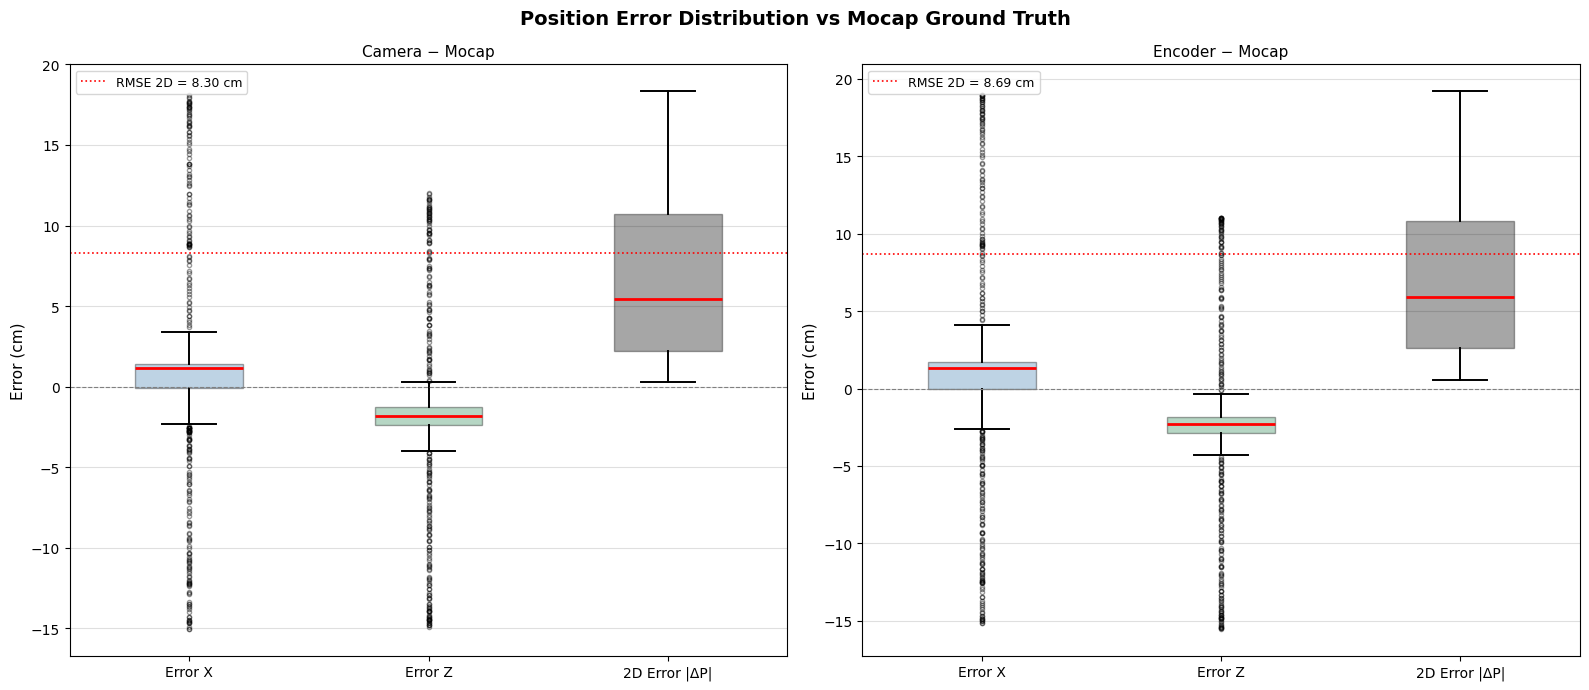

In [50]:
# Cell 38
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Position Error Distribution vs Mocap Ground Truth", fontsize=14, fontweight='bold')

# FIX (Bug 5): loop variables renamed ex/ez/e2d — no longer shadows outer err_x/err_z/err_2d
for ax, (ex, ez, e2d, title) in zip(axes, [
    (err_mc_x, err_mc_z, err_mc_2d, "Camera − Mocap"),
    (err_me_x, err_me_z, err_me_2d, "Encoder − Mocap"),
]):
    bp = ax.boxplot(
        [ex, ez, e2d],
        labels=["Error X", "Error Z", "2D Error |ΔP|"],
        patch_artist=True, notch=False, widths=0.45,
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        flierprops=dict(marker='o', markersize=3, linestyle='none', alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], ['steelblue', 'seagreen', 'black']):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)

    rmse = np.sqrt((e2d**2).mean())
    ax.axhline(rmse, color='red', lw=1.2, ls=':', label=f'RMSE 2D = {rmse:.2f} cm')
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_ylabel("Error (cm)", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('plot_mocap_error_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()